# EDA 03 — Feature Analysis & Generation Mix

> **Read-only EDA.** Explores the relationship between key features and PLD targets.
> Run the ETL pipeline before this notebook.

**Prerequisites**
```bash
python -m etl.run_pipeline --start 2005-01-01 --end 2024-12-31
python -m etl.gold
```

**Sections**
1. Setup & data loading
2. Feature–target correlation matrix (Spearman)
3. ENA anomaly — the key predictor
4. Reservoir levels & critical thresholds
5. Generation mix over time
6. Load demand vs PLD
7. Weather: precipitation & temperature
8. Cross-subsystem feature patterns
9. Seasonal feature distributions (dry vs. wet season)

In [1]:
import sys
from pathlib import Path

import duckdb
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

ROOT = Path("..").resolve()
sys.path.insert(0, str(ROOT))

from ml.train import FEATURE_COLS, TARGET_COLS

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 130

SUBSYSTEMS = ["SE/CO", "S", "NE", "N"]
COLORS = {"SE/CO": "#1f77b4", "S": "#2ca02c", "NE": "#ff7f0e", "N": "#9467bd"}

## 1. Setup & Data Loading

In [2]:
train_path = ROOT / "data" / "gold" / "abt_train.parquet"
silver_path = ROOT / "data" / "silver" / "features.parquet"

for p in [train_path, silver_path]:
    if not p.exists():
        raise FileNotFoundError(f"{p} — run etl/run_pipeline.py first")

con = duckdb.connect()
abt = con.execute(f"SELECT * FROM read_parquet('{train_path}')").fetchdf()
silver = con.execute(f"SELECT * FROM read_parquet('{silver_path}')").fetchdf()
con.close()

abt["week_start"] = pd.to_datetime(abt["week_start"])
silver["week_start"] = pd.to_datetime(silver["week_start"])

abt = abt.dropna(subset=FEATURE_COLS + TARGET_COLS).reset_index(drop=True)

print(f"ABT train:  {len(abt):,} rows  ({abt['week_start'].min().date()} → {abt['week_start'].max().date()})")
print(f"Silver:     {len(silver):,} rows  ({silver['week_start'].min().date()} → {silver['week_start'].max().date()})")
print(f"Subsystems: {abt['subsystem'].unique().tolist()}")
print(f"Features:   {len(FEATURE_COLS)} | Targets: {len(TARGET_COLS)}")

ABT train:  3,544 rows  (2007-01-05 → 2023-12-29)
Silver:     3,964 rows  (2006-01-06 → 2024-12-27)
Subsystems: ['N', 'NE', 'S', 'SE/CO']
Features:   61 | Targets: 4


## 2. Feature–Target Correlation Matrix (Spearman)

Spearman (rank) correlation is used because PLD is right-skewed and non-linear.
Positive = feature rises → PLD rises. Negative = feature rises → PLD falls.

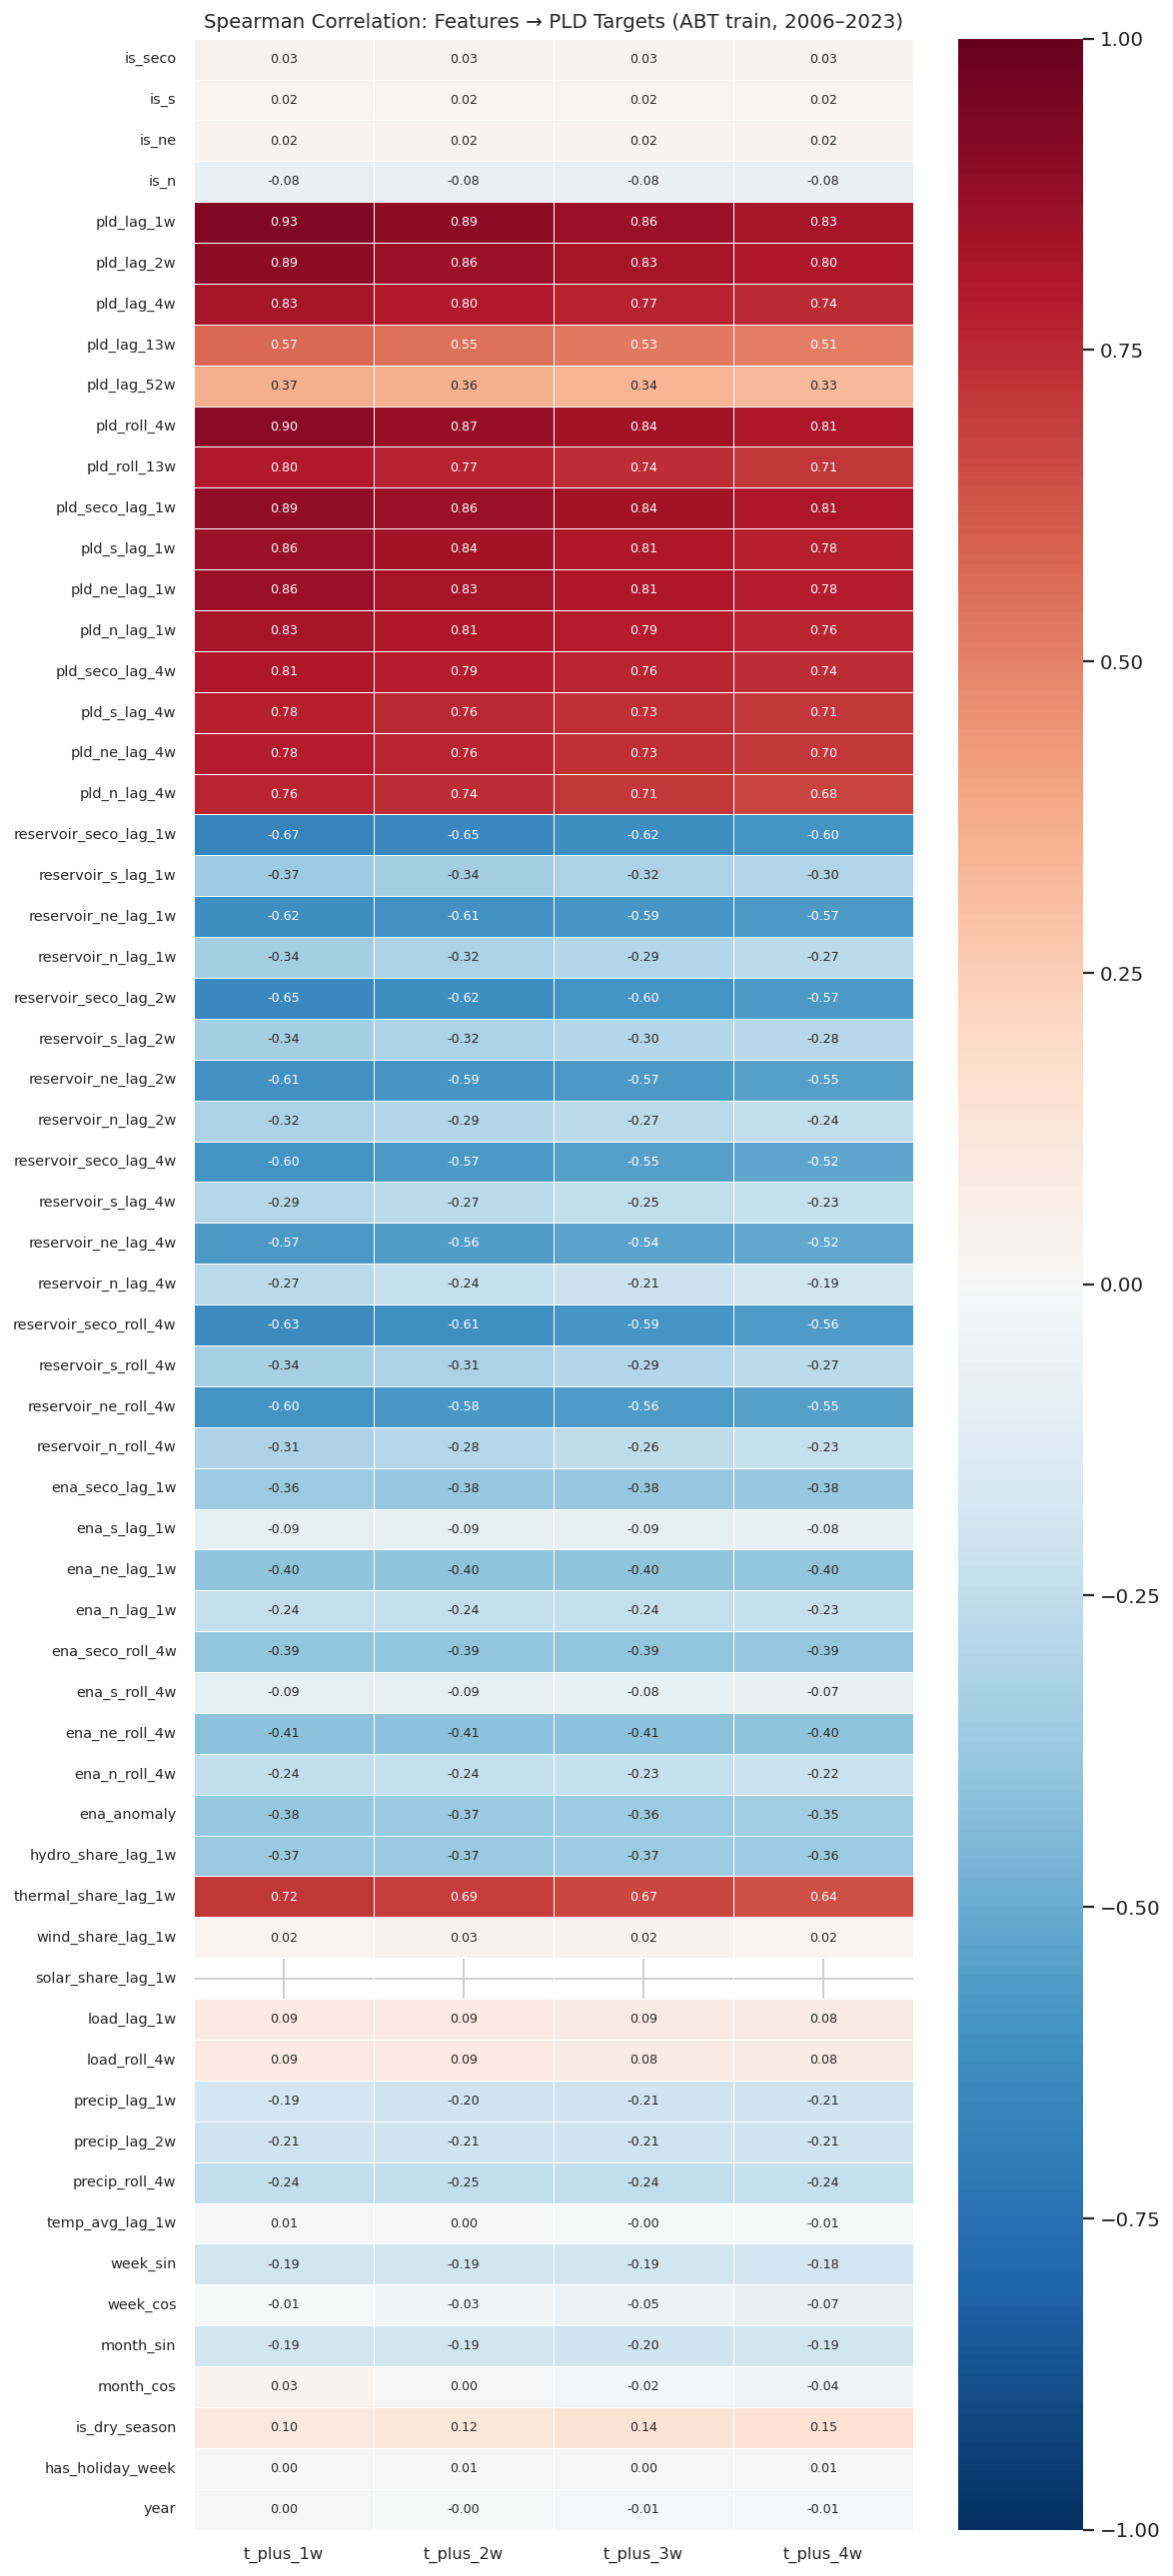

In [3]:
# Compute Spearman correlations between all features and the 4 targets
corr_data = abt[FEATURE_COLS + TARGET_COLS].copy()
corr_matrix = corr_data.corr(method="spearman")

# Extract only features → targets sub-block
feat_tgt_corr = corr_matrix.loc[FEATURE_COLS, TARGET_COLS]

fig, ax = plt.subplots(figsize=(9, 20))
sns.heatmap(
    feat_tgt_corr,
    annot=True, fmt=".2f", annot_kws={"size": 7},
    cmap="RdBu_r", center=0, vmin=-1, vmax=1,
    linewidths=0.4, ax=ax
)
ax.set_xticklabels([c.replace("pld_", "") for c in TARGET_COLS], fontsize=9)
ax.set_yticklabels(ax.get_yticklabels(), fontsize=8, rotation=0)
ax.set_title("Spearman Correlation: Features → PLD Targets (ABT train, 2006–2023)", fontsize=11)
plt.tight_layout()
plt.show()

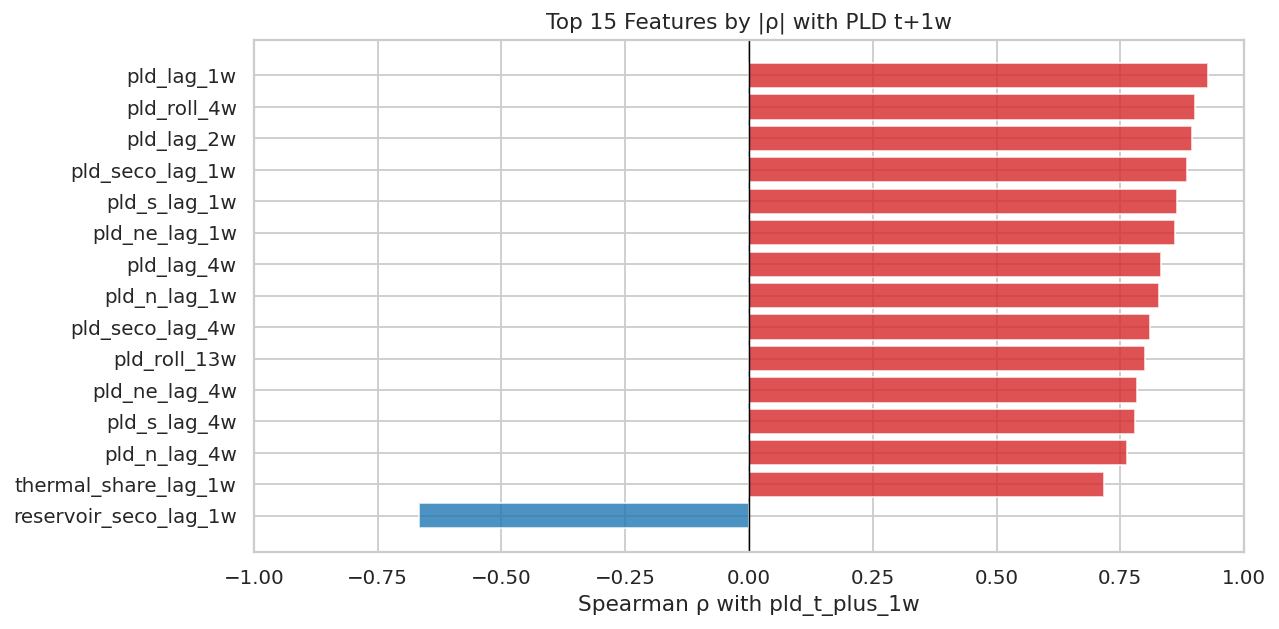

Top 15 features (by |ρ| with t+1w):
  pld_lag_1w                         : ρ = +0.927
  pld_roll_4w                        : ρ = +0.900
  pld_lag_2w                         : ρ = +0.895
  pld_seco_lag_1w                    : ρ = +0.886
  pld_s_lag_1w                       : ρ = +0.864
  pld_ne_lag_1w                      : ρ = +0.859
  pld_lag_4w                         : ρ = +0.832
  pld_n_lag_1w                       : ρ = +0.829
  pld_seco_lag_4w                    : ρ = +0.810
  pld_roll_13w                       : ρ = +0.800
  pld_ne_lag_4w                      : ρ = +0.784
  pld_s_lag_4w                       : ρ = +0.779
  pld_n_lag_4w                       : ρ = +0.763
  thermal_share_lag_1w               : ρ = +0.717
  reservoir_seco_lag_1w              : ρ = -0.667


In [4]:
# Top 15 most informative features for t+1w (by absolute correlation)
top_features = feat_tgt_corr["pld_t_plus_1w"].abs().sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(
    top_features.index[::-1],
    feat_tgt_corr.loc[top_features.index[::-1], "pld_t_plus_1w"],
    color=["#d62728" if v > 0 else "#1f77b4" for v in feat_tgt_corr.loc[top_features.index[::-1], "pld_t_plus_1w"]],
    alpha=0.8
)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Spearman ρ with pld_t_plus_1w")
ax.set_title("Top 15 Features by |ρ| with PLD t+1w")
ax.set_xlim(-1, 1)
plt.tight_layout()
plt.show()

print("Top 15 features (by |ρ| with t+1w):")
for feat, rho in top_features.items():
    print(f"  {feat:35s}: ρ = {feat_tgt_corr.loc[feat, 'pld_t_plus_1w']:+.3f}")

## 3. ENA Anomaly — The Key Predictor

`ena_anomaly` = rolling 4-week ENA / historical average for the same week-of-year.
- Values < 1 → below-normal inflows (drought) → high PLD
- Values > 1 → above-normal inflows (wet season) → low PLD

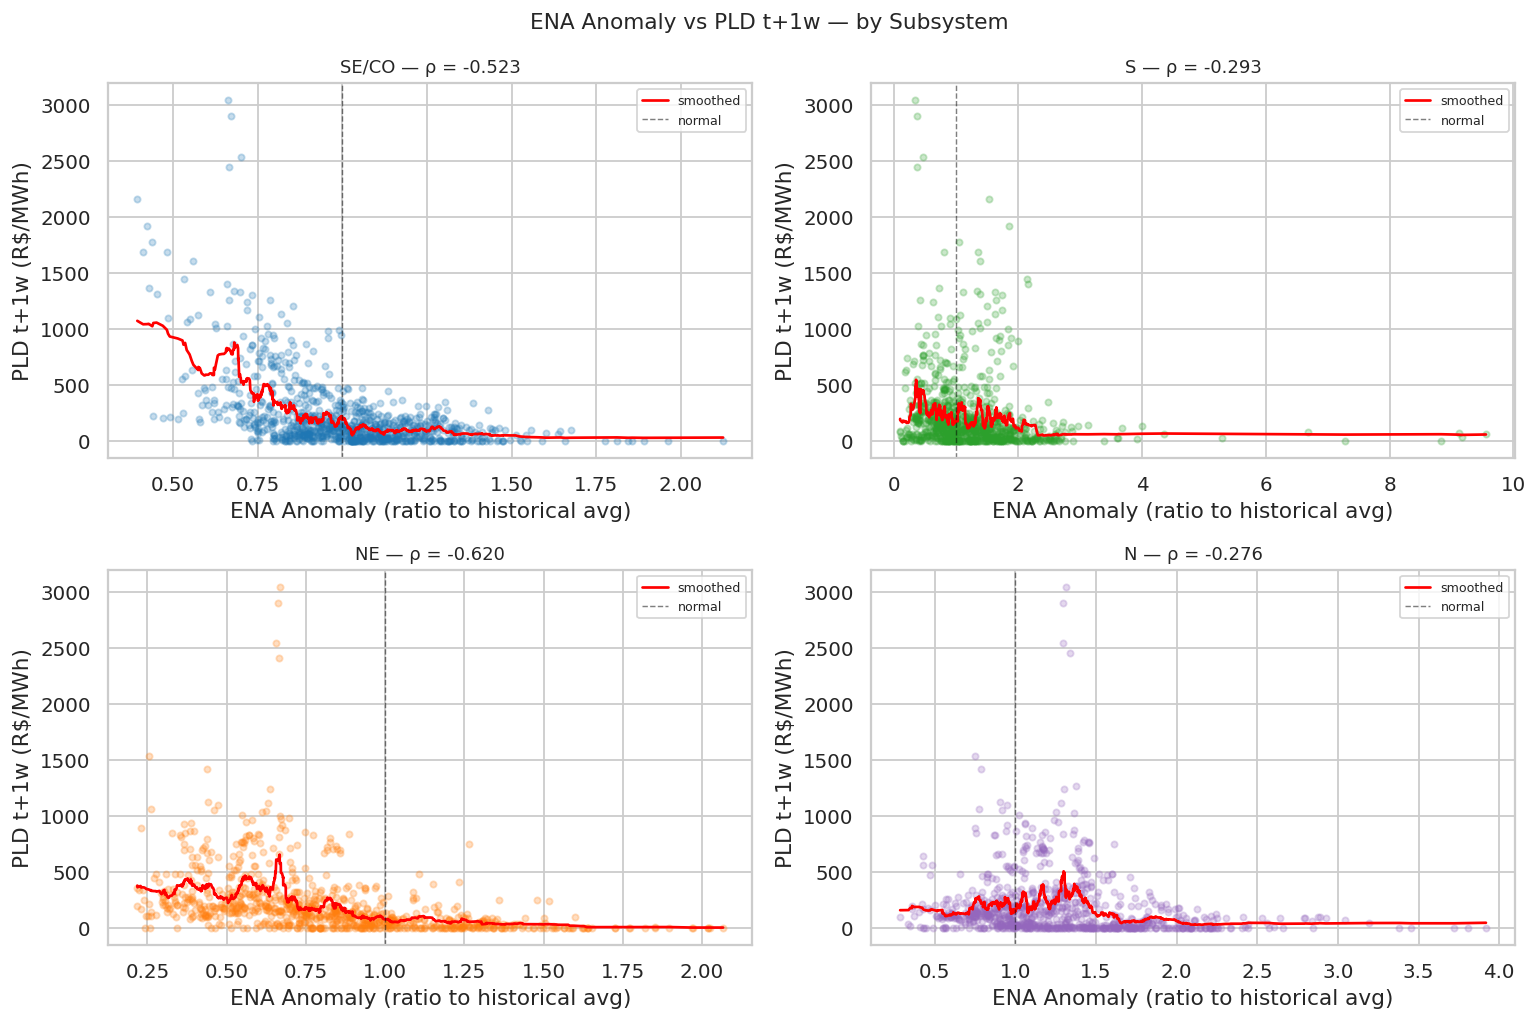

In [5]:
# Scatter: ENA anomaly vs PLD t+1w, by subsystem
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharey=False)
axes = axes.flatten()

for ax, sub in zip(axes, SUBSYSTEMS):
    mask = abt["subsystem"] == sub
    x = abt.loc[mask, "ena_anomaly"]
    y = abt.loc[mask, "pld_t_plus_1w"]
    ax.scatter(x, y, alpha=0.25, s=12, color=COLORS[sub])
    # Lowess-style trend via pandas rolling
    df_tmp = pd.DataFrame({"x": x.values, "y": y.values}).sort_values("x")
    df_tmp["y_roll"] = df_tmp["y"].rolling(30, center=True, min_periods=5).mean()
    ax.plot(df_tmp["x"], df_tmp["y_roll"], color="red", linewidth=1.5, label="smoothed")
    ax.axvline(1, color="black", linestyle="--", linewidth=0.8, alpha=0.5, label="normal")
    rho = x.corr(y, method="spearman")
    ax.set_title(f"{sub} — ρ = {rho:.3f}", fontsize=10)
    ax.set_xlabel("ENA Anomaly (ratio to historical avg)")
    ax.set_ylabel("PLD t+1w (R$/MWh)")
    ax.legend(fontsize=7)

plt.suptitle("ENA Anomaly vs PLD t+1w — by Subsystem", fontsize=12)
plt.tight_layout()
plt.show()

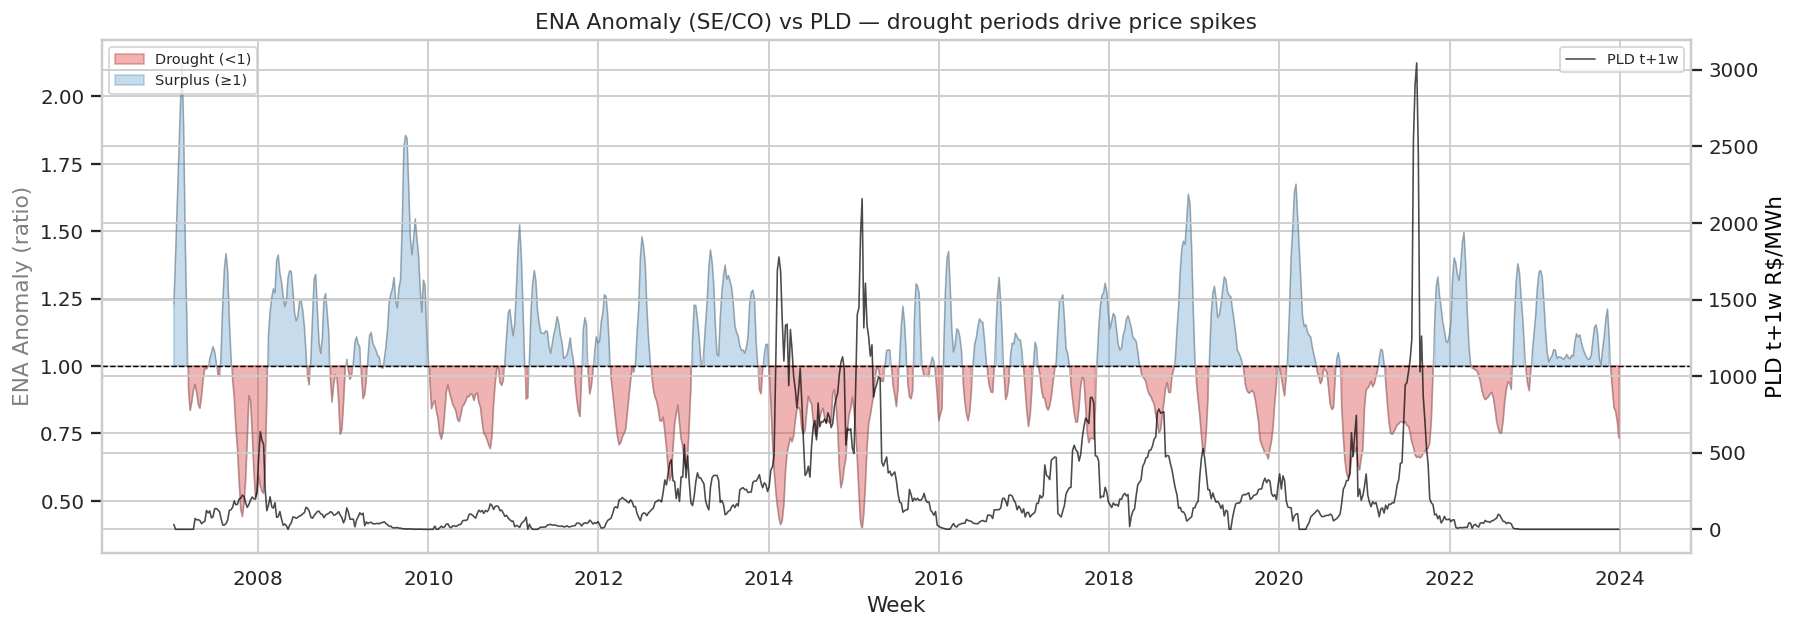

In [6]:
# Time series: ENA anomaly (SE/CO) overlaid with PLD — dual axis
mask_seco = abt["subsystem"] == "SE/CO"
seco = abt[mask_seco].sort_values("week_start")

fig, ax1 = plt.subplots(figsize=(14, 5))

ax2 = ax1.twinx()
ax1.fill_between(seco["week_start"], seco["ena_anomaly"], 1,
                 where=seco["ena_anomaly"] < 1, alpha=0.35, color="#d62728", label="Drought (<1)")
ax1.fill_between(seco["week_start"], seco["ena_anomaly"], 1,
                 where=seco["ena_anomaly"] >= 1, alpha=0.25, color="#1f77b4", label="Surplus (≥1)")
ax1.plot(seco["week_start"], seco["ena_anomaly"], color="gray", linewidth=0.7, alpha=0.6)
ax1.axhline(1, color="black", linewidth=0.8, linestyle="--")

ax2.plot(seco["week_start"], seco["pld_t_plus_1w"], color="black", linewidth=0.9, alpha=0.7, label="PLD t+1w")

ax1.set_xlabel("Week")
ax1.set_ylabel("ENA Anomaly (ratio)", color="gray")
ax2.set_ylabel("PLD t+1w R$/MWh", color="black")
ax1.set_title("ENA Anomaly (SE/CO) vs PLD — drought periods drive price spikes")
ax1.legend(loc="upper left", fontsize=8)
ax2.legend(loc="upper right", fontsize=8)
plt.tight_layout()
plt.show()

## 4. Reservoir Levels & Critical Thresholds

Reservoir storage (% of total capacity) is the medium-term energy buffer.
When below ~30% the risk of rationing (and PLD spike) increases sharply.

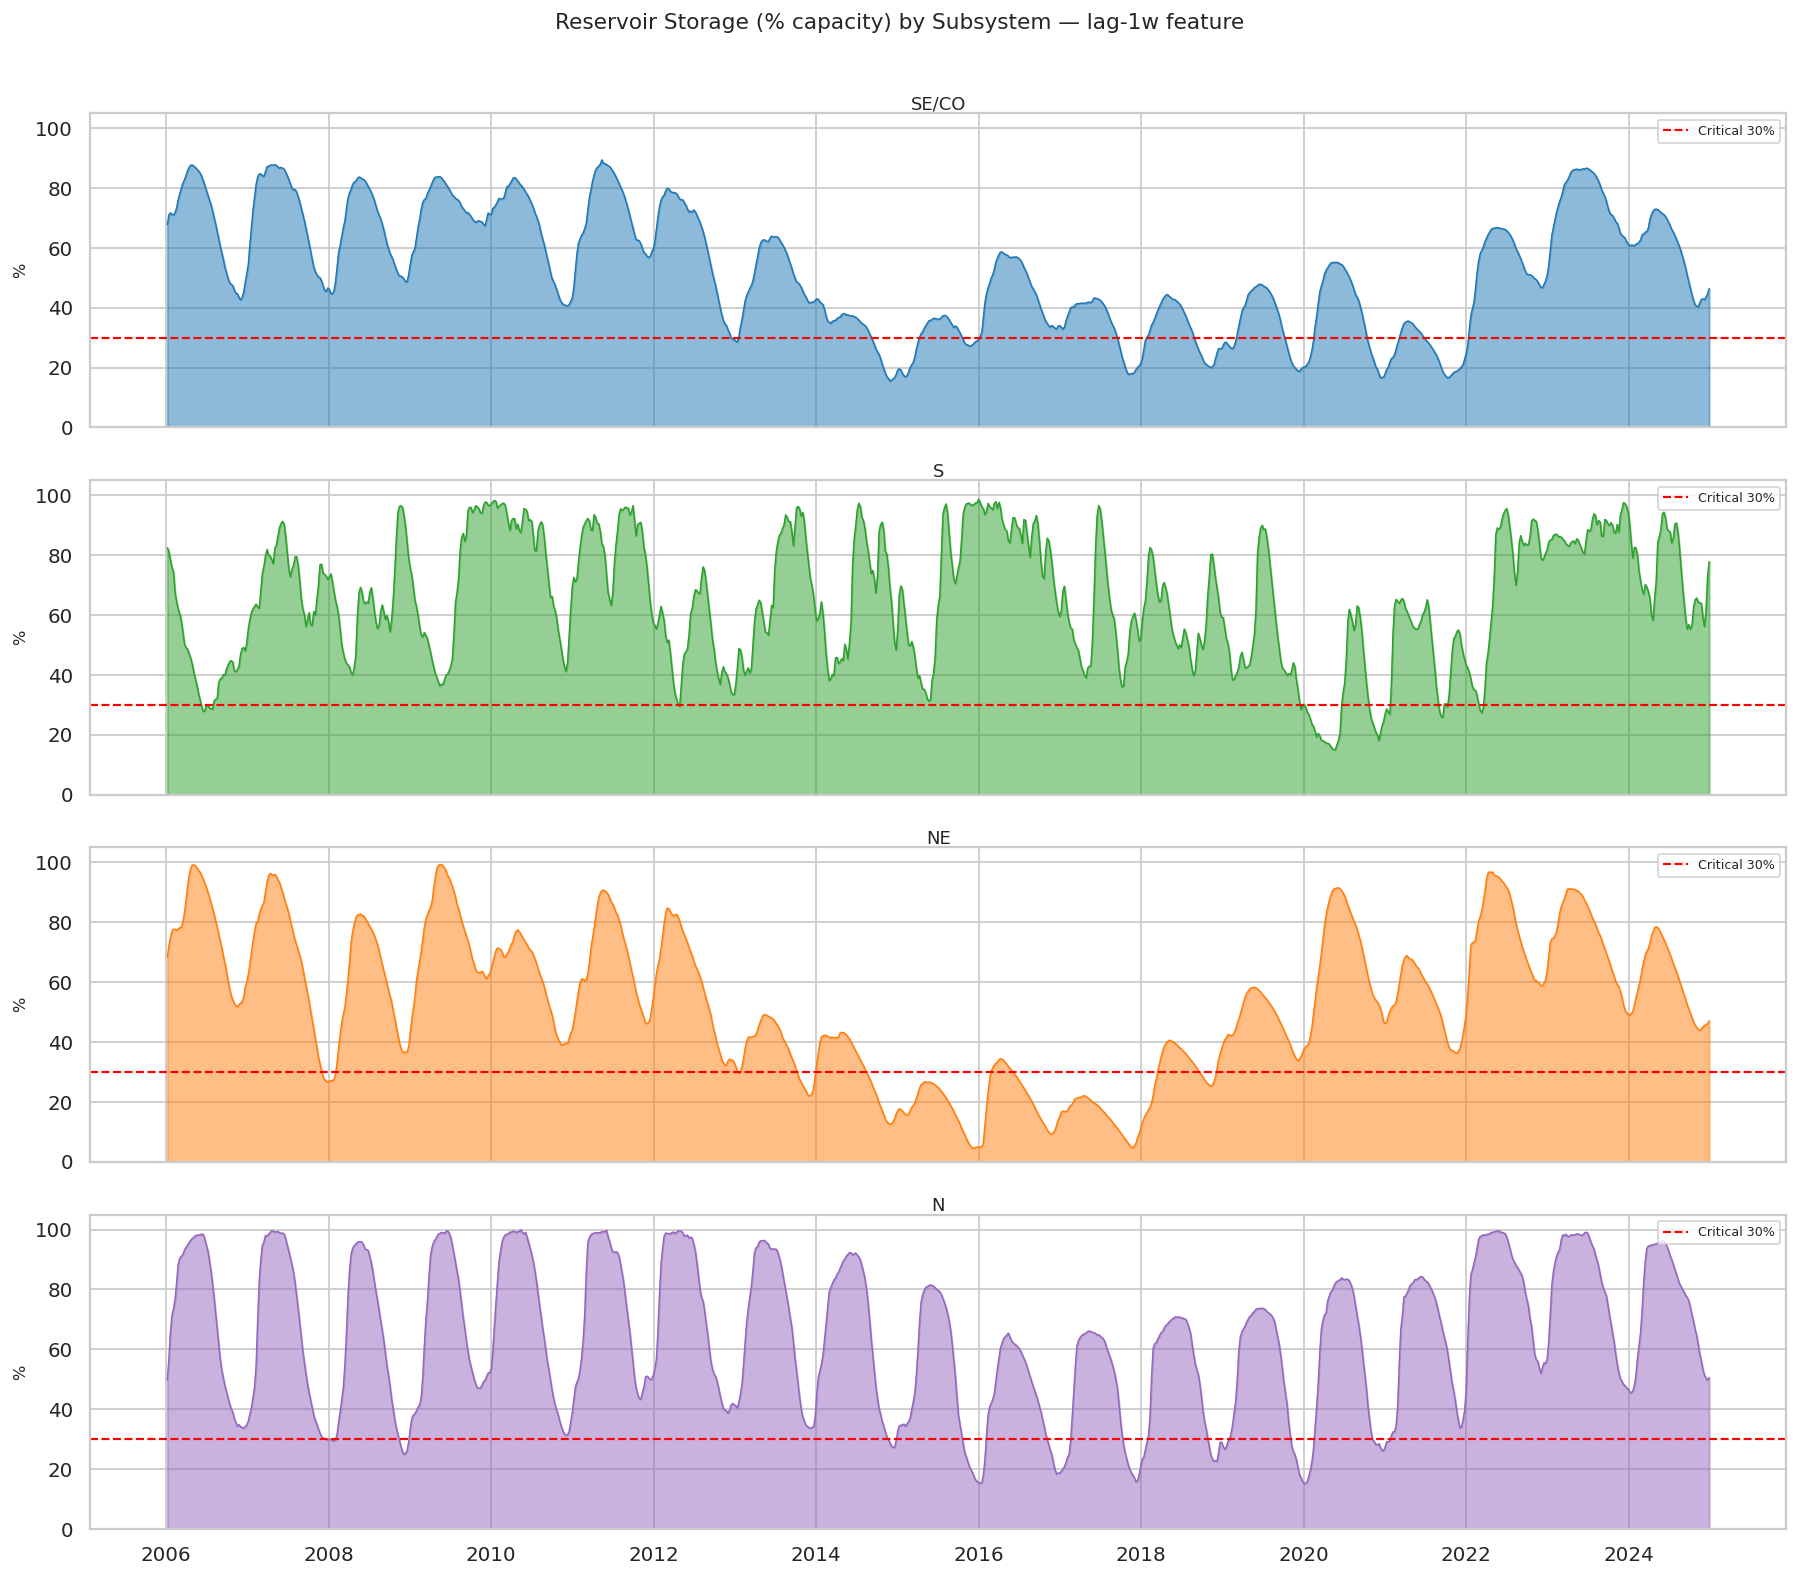

In [7]:
# Time series of reservoir % for each subsystem — use silver for full history
res_cols = {"SE/CO": "reservoir_seco_lag_1w", "S": "reservoir_s_lag_1w",
            "NE": "reservoir_ne_lag_1w", "N": "reservoir_n_lag_1w"}

fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)

for ax, sub in zip(axes, SUBSYSTEMS):
    col = res_cols[sub]
    data = silver[silver["subsystem"] == sub].sort_values("week_start")
    ax.fill_between(data["week_start"], data[col], alpha=0.5, color=COLORS[sub])
    ax.plot(data["week_start"], data[col], linewidth=0.8, color=COLORS[sub])
    ax.axhline(30, color="red", linestyle="--", linewidth=1.2, label="Critical 30%")
    ax.set_ylabel("%", fontsize=9)
    ax.set_title(f"{sub}", fontsize=10, pad=2)
    ax.set_ylim(0, 105)
    ax.legend(fontsize=7, loc="upper right")
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.xaxis.set_major_locator(mdates.YearLocator(2))

plt.suptitle("Reservoir Storage (% capacity) by Subsystem — lag-1w feature", fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

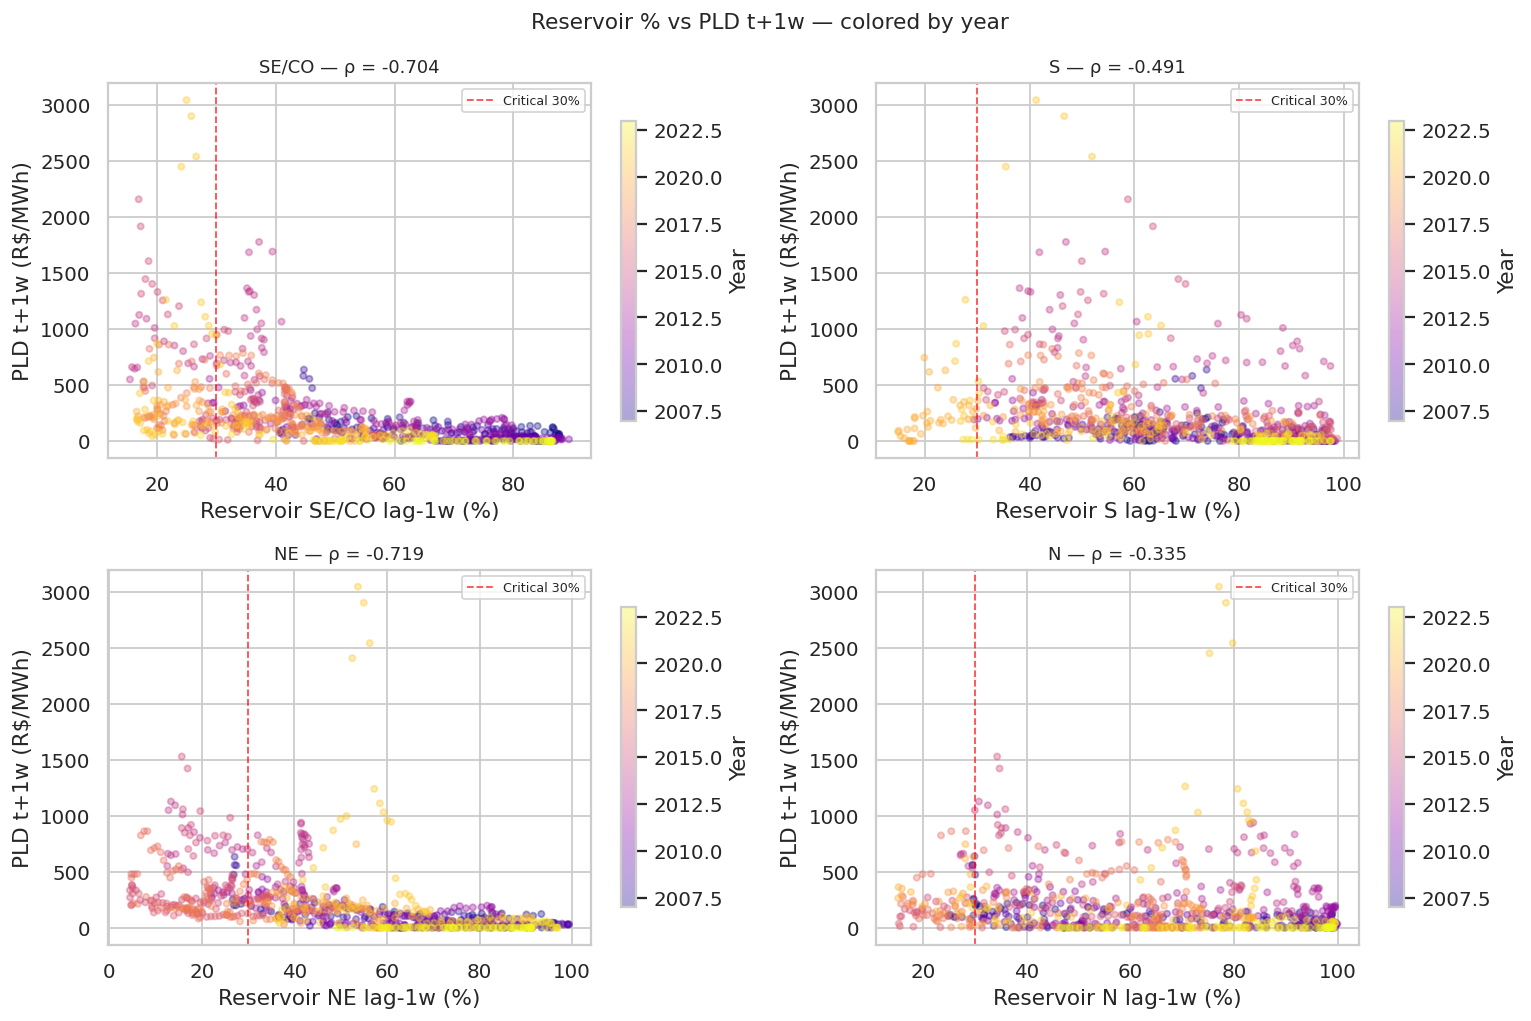

In [8]:
# Reservoir vs PLD scatter — all subsystems
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for ax, sub in zip(axes, SUBSYSTEMS):
    col = res_cols[sub]
    mask = abt["subsystem"] == sub
    x = abt.loc[mask, col]
    y = abt.loc[mask, "pld_t_plus_1w"]

    # Color points by year to show temporal drift
    years = abt.loc[mask, "week_start"].dt.year
    sc = ax.scatter(x, y, c=years, cmap="plasma", alpha=0.35, s=12)
    plt.colorbar(sc, ax=ax, label="Year", shrink=0.8)
    ax.axvline(30, color="red", linestyle="--", linewidth=1, alpha=0.7, label="Critical 30%")

    rho = x.corr(y, method="spearman")
    ax.set_title(f"{sub} — ρ = {rho:.3f}", fontsize=10)
    ax.set_xlabel(f"Reservoir {sub} lag-1w (%)")
    ax.set_ylabel("PLD t+1w (R$/MWh)")
    ax.legend(fontsize=7)

plt.suptitle("Reservoir % vs PLD t+1w — colored by year", fontsize=12)
plt.tight_layout()
plt.show()

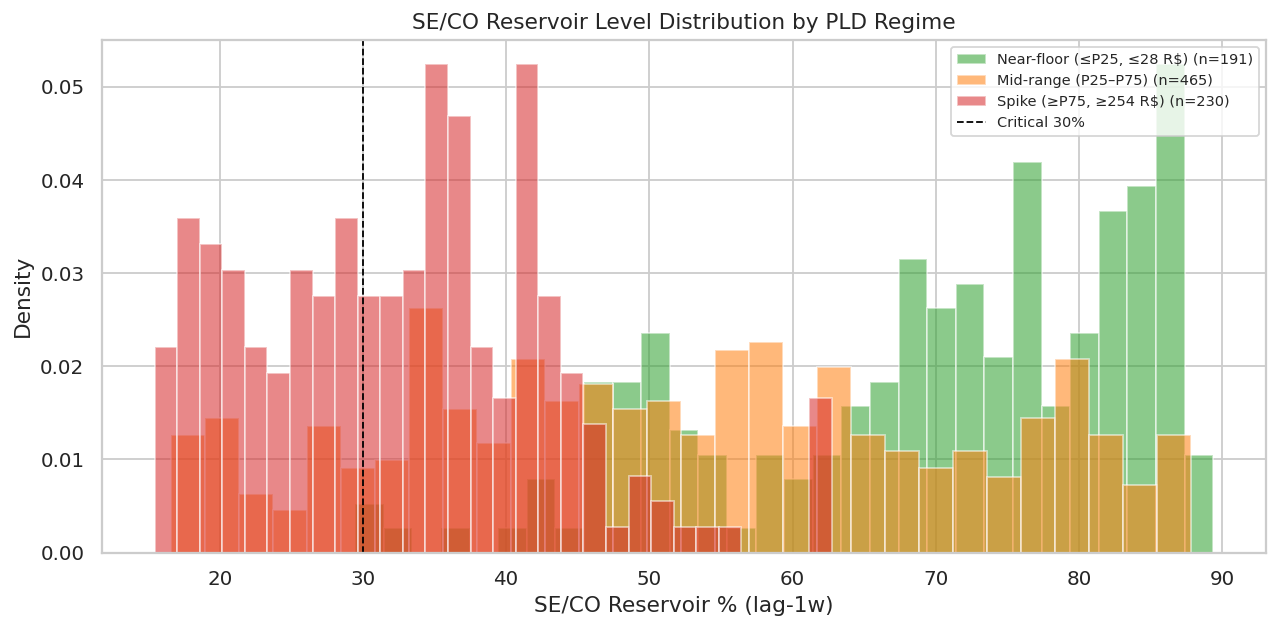

In [9]:
# Distribution of reservoir % stratified by PLD regime (floor vs mid vs spike)
col_pld = "pld_t_plus_1w"
col_res = "reservoir_seco_lag_1w"
p25 = abt[col_pld].quantile(0.25)
p75 = abt[col_pld].quantile(0.75)

regimes = {
    f"Near-floor (≤P25, ≤{p25:.0f} R$)": abt[col_pld] <= p25,
    f"Mid-range (P25–P75)": (abt[col_pld] > p25) & (abt[col_pld] < p75),
    f"Spike (≥P75, ≥{p75:.0f} R$)": abt[col_pld] >= p75,
}

fig, ax = plt.subplots(figsize=(10, 5))
palette = ["#2ca02c", "#ff7f0e", "#d62728"]
for (label, mask), color in zip(regimes.items(), palette):
    data = abt.loc[mask & (abt["subsystem"] == "SE/CO"), col_res].dropna()
    ax.hist(data, bins=30, alpha=0.55, color=color, label=f"{label} (n={len(data)})", density=True)

ax.axvline(30, color="black", linestyle="--", linewidth=1, label="Critical 30%")
ax.set_xlabel("SE/CO Reservoir % (lag-1w)")
ax.set_ylabel("Density")
ax.set_title("SE/CO Reservoir Level Distribution by PLD Regime")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## 5. Generation Mix Over Time

Brazil's grid is ~60% hydroelectric. As wind and solar scale up, the mix shifts —
increasing resilience to droughts but also changing PLD dynamics.

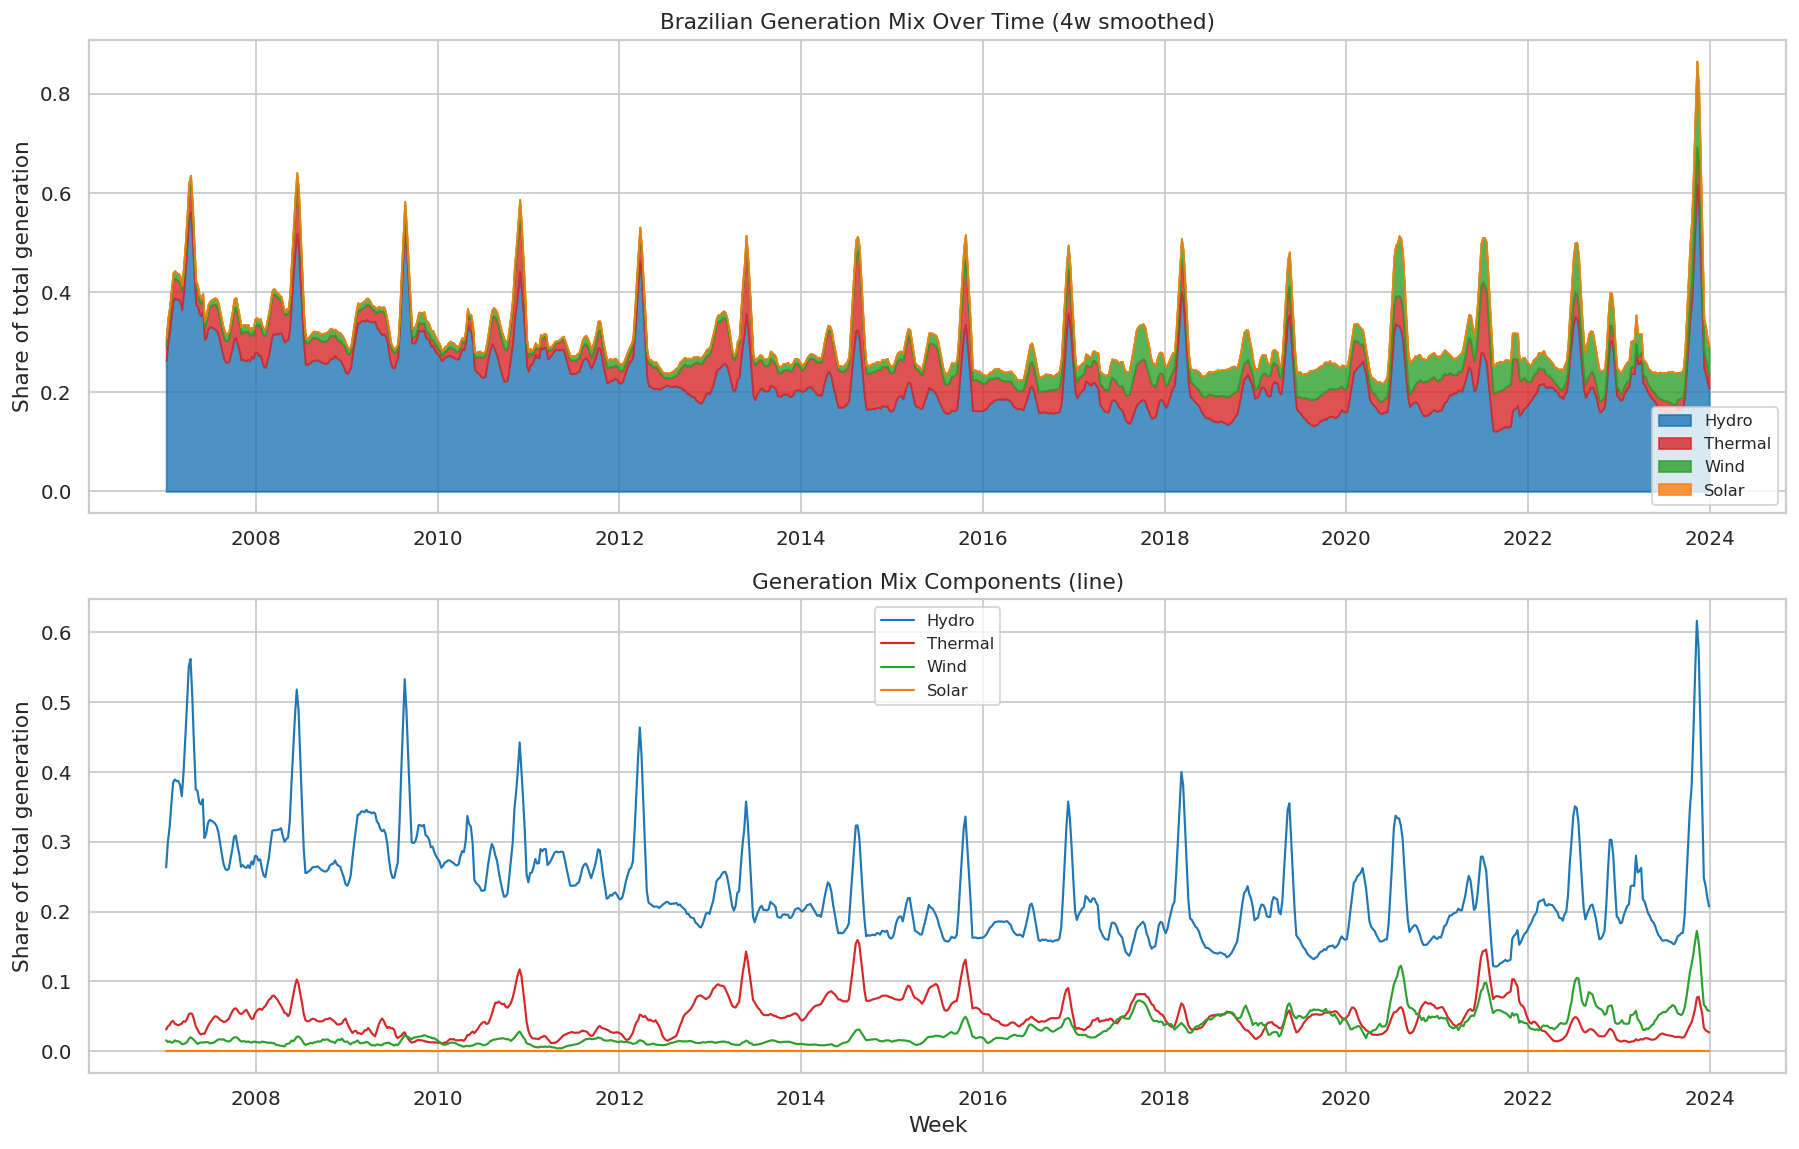

In [10]:
# Stacked area chart of generation mix over time (national, lag-1w features)
gen_cols = {
    "Hydro": "hydro_share_lag_1w",
    "Thermal": "thermal_share_lag_1w",
    "Wind": "wind_share_lag_1w",
    "Solar": "solar_share_lag_1w",
}
gen_colors = {"Hydro": "#1f77b4", "Thermal": "#d62728", "Wind": "#2ca02c", "Solar": "#ff7f0e"}

# Use SE/CO rows (gen mix is national, same across subsystems)
gen_data = abt[abt["subsystem"] == "SE/CO"].sort_values("week_start")

# 4-week rolling average for smoother chart
for col in gen_cols.values():
    gen_data[col] = gen_data[col].rolling(4, center=True, min_periods=1).mean()

fig, axes = plt.subplots(2, 1, figsize=(14, 9))

# Stacked area
bottom = np.zeros(len(gen_data))
for label, col in gen_cols.items():
    vals = gen_data[col].fillna(0).values
    axes[0].fill_between(gen_data["week_start"], bottom, bottom + vals,
                         alpha=0.8, color=gen_colors[label], label=label)
    bottom += vals

axes[0].set_ylabel("Share of total generation")
axes[0].set_title("Brazilian Generation Mix Over Time (4w smoothed)")
axes[0].legend(loc="lower right", fontsize=9)
axes[0].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
axes[0].xaxis.set_major_locator(mdates.YearLocator(2))

# Individual lines
for label, col in gen_cols.items():
    axes[1].plot(gen_data["week_start"], gen_data[col],
                 color=gen_colors[label], linewidth=1.2, label=label)
axes[1].set_ylabel("Share of total generation")
axes[1].set_xlabel("Week")
axes[1].set_title("Generation Mix Components (line)")
axes[1].legend(fontsize=9)
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
axes[1].xaxis.set_major_locator(mdates.YearLocator(2))

plt.tight_layout()
plt.show()

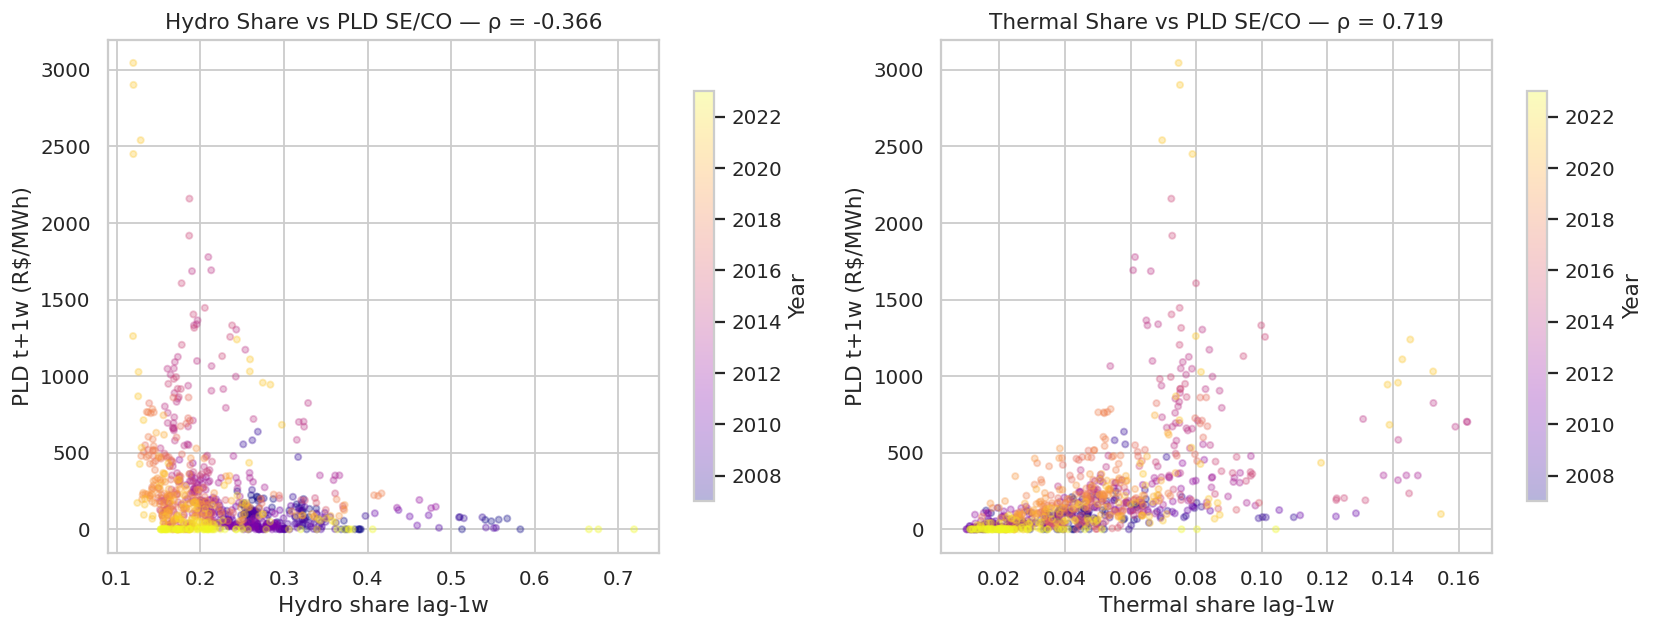

Note: High thermal share → expensive dispatch → high PLD (positive ρ expected)
High hydro share → cheap dispatch → lower PLD (negative ρ expected)


In [11]:
# Hydro share vs PLD — non-linear relationship expected
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Scatter
x_hydro = abt[abt["subsystem"] == "SE/CO"]["hydro_share_lag_1w"]
y_pld   = abt[abt["subsystem"] == "SE/CO"]["pld_t_plus_1w"]
years   = abt[abt["subsystem"] == "SE/CO"]["week_start"].dt.year

sc = axes[0].scatter(x_hydro, y_pld, c=years, cmap="plasma", alpha=0.3, s=12)
plt.colorbar(sc, ax=axes[0], label="Year", shrink=0.8)
rho = x_hydro.corr(y_pld, method="spearman")
axes[0].set_xlabel("Hydro share lag-1w")
axes[0].set_ylabel("PLD t+1w (R$/MWh)")
axes[0].set_title(f"Hydro Share vs PLD SE/CO — ρ = {rho:.3f}")

# Thermal share vs PLD (positive correlation expected)
x_thermal = abt[abt["subsystem"] == "SE/CO"]["thermal_share_lag_1w"]
sc2 = axes[1].scatter(x_thermal, y_pld, c=years, cmap="plasma", alpha=0.3, s=12)
plt.colorbar(sc2, ax=axes[1], label="Year", shrink=0.8)
rho2 = x_thermal.corr(y_pld, method="spearman")
axes[1].set_xlabel("Thermal share lag-1w")
axes[1].set_ylabel("PLD t+1w (R$/MWh)")
axes[1].set_title(f"Thermal Share vs PLD SE/CO — ρ = {rho2:.3f}")

plt.tight_layout()
plt.show()
print("Note: High thermal share → expensive dispatch → high PLD (positive ρ expected)")
print("High hydro share → cheap dispatch → lower PLD (negative ρ expected)")

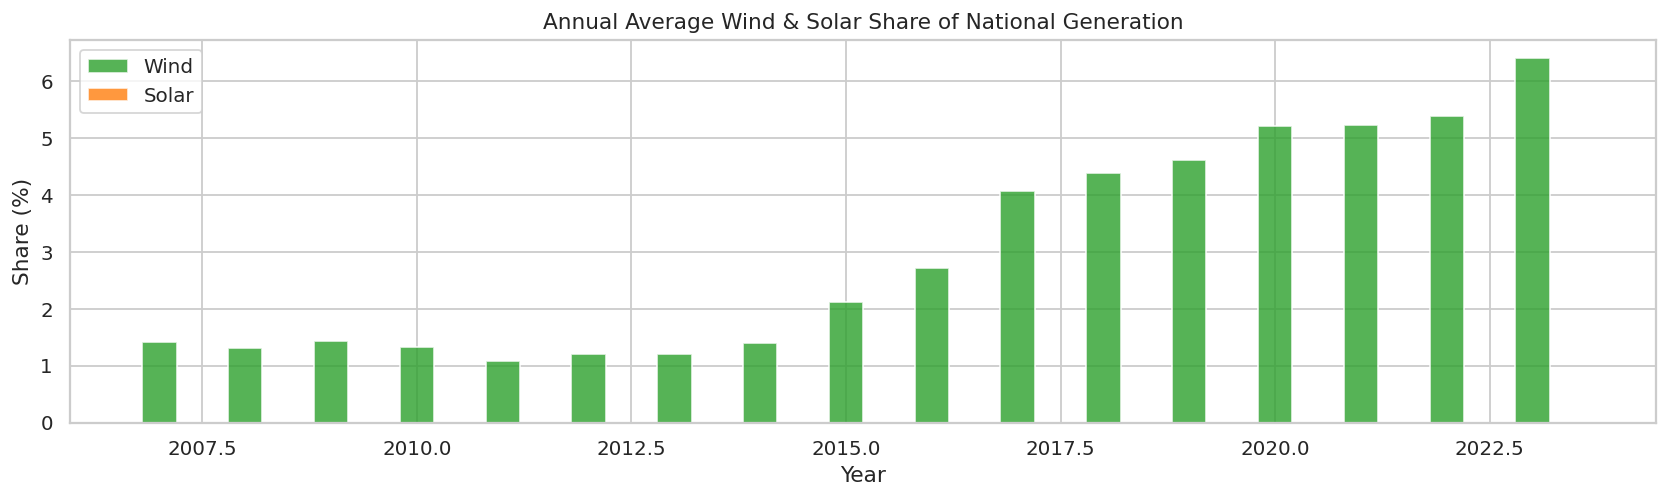

In [12]:
# Wind + Solar growth — long-term trend
fig, ax = plt.subplots(figsize=(13, 4))

for label, col in {"Wind": "wind_share_lag_1w", "Solar": "solar_share_lag_1w"}.items():
    d = gen_data.copy()
    # Annual mean
    d["year"] = d["week_start"].dt.year
    annual = d.groupby("year")[col].mean().reset_index()
    ax.bar(annual["year"] + (0 if label == "Wind" else 0.4),
           annual[col] * 100, width=0.4,
           color=gen_colors[label], alpha=0.8, label=label)

ax.set_xlabel("Year")
ax.set_ylabel("Share (%)")
ax.set_title("Annual Average Wind & Solar Share of National Generation")
ax.legend()
plt.tight_layout()
plt.show()

## 6. Load Demand vs PLD

Electricity demand drives the merit-order dispatch. High load → higher marginal plant → higher PLD.
But the relationship is mediated by hydro availability.

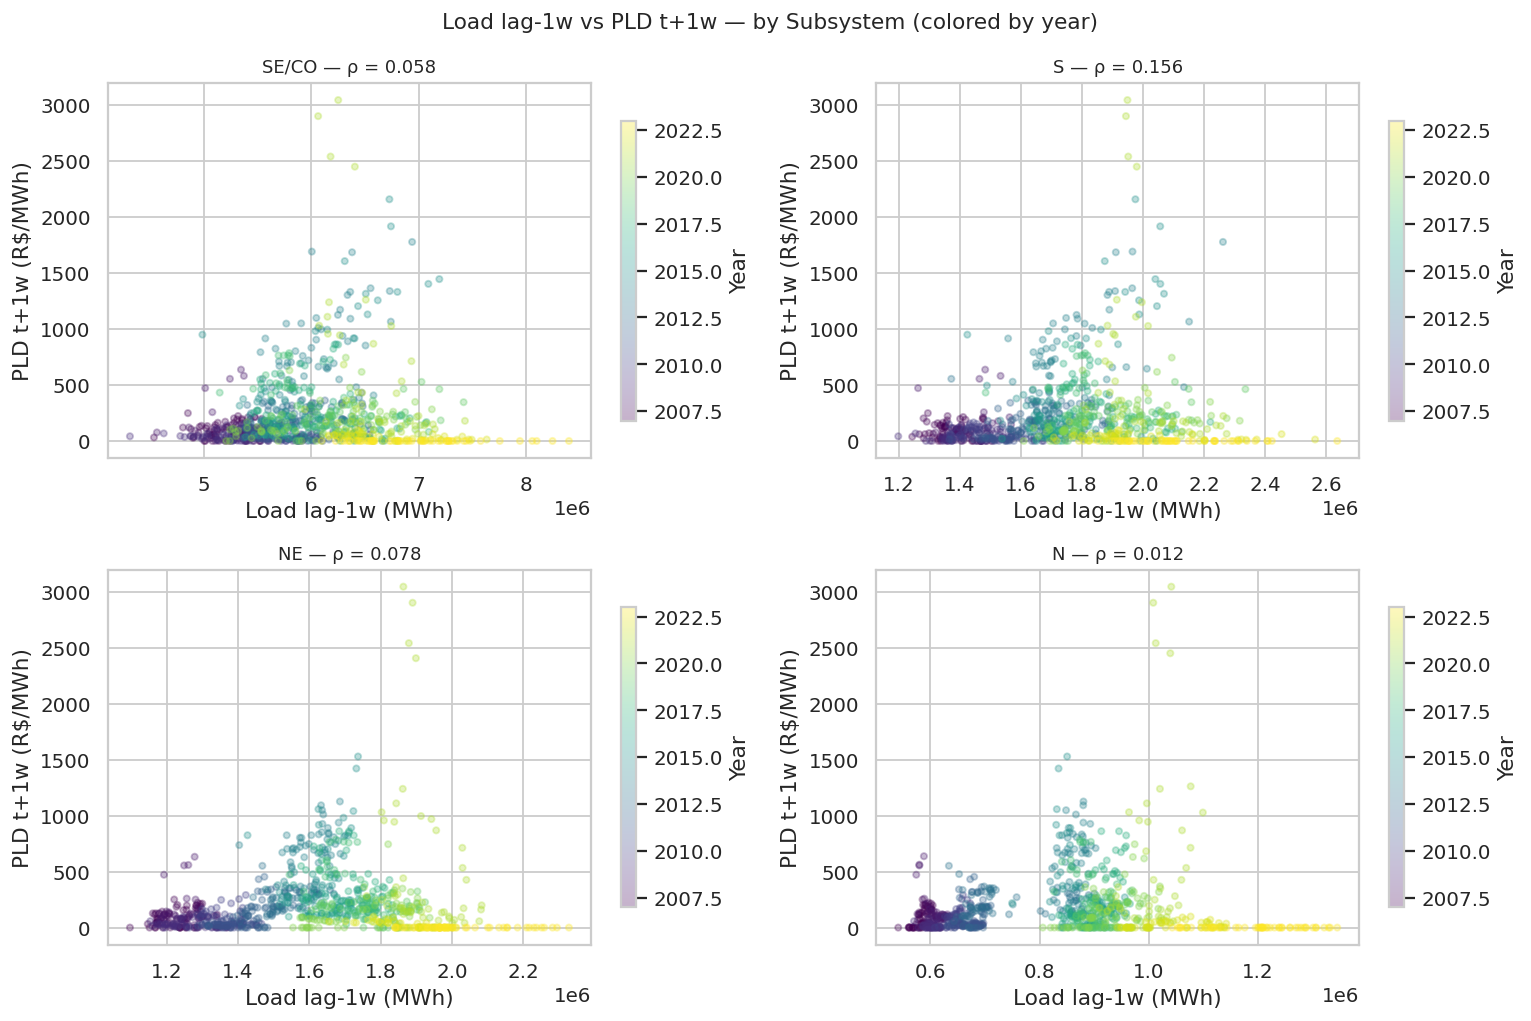

In [13]:
# Load vs PLD scatter — all subsystems
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for ax, sub in zip(axes, SUBSYSTEMS):
    mask = abt["subsystem"] == sub
    x = abt.loc[mask, "load_lag_1w"]
    y = abt.loc[mask, "pld_t_plus_1w"]
    years = abt.loc[mask, "week_start"].dt.year
    sc = ax.scatter(x, y, c=years, cmap="viridis", alpha=0.3, s=12)
    plt.colorbar(sc, ax=ax, label="Year", shrink=0.8)
    rho = x.corr(y, method="spearman")
    ax.set_title(f"{sub} — ρ = {rho:.3f}", fontsize=10)
    ax.set_xlabel("Load lag-1w (MWh)")
    ax.set_ylabel("PLD t+1w (R$/MWh)")

plt.suptitle("Load lag-1w vs PLD t+1w — by Subsystem (colored by year)", fontsize=12)
plt.tight_layout()
plt.show()

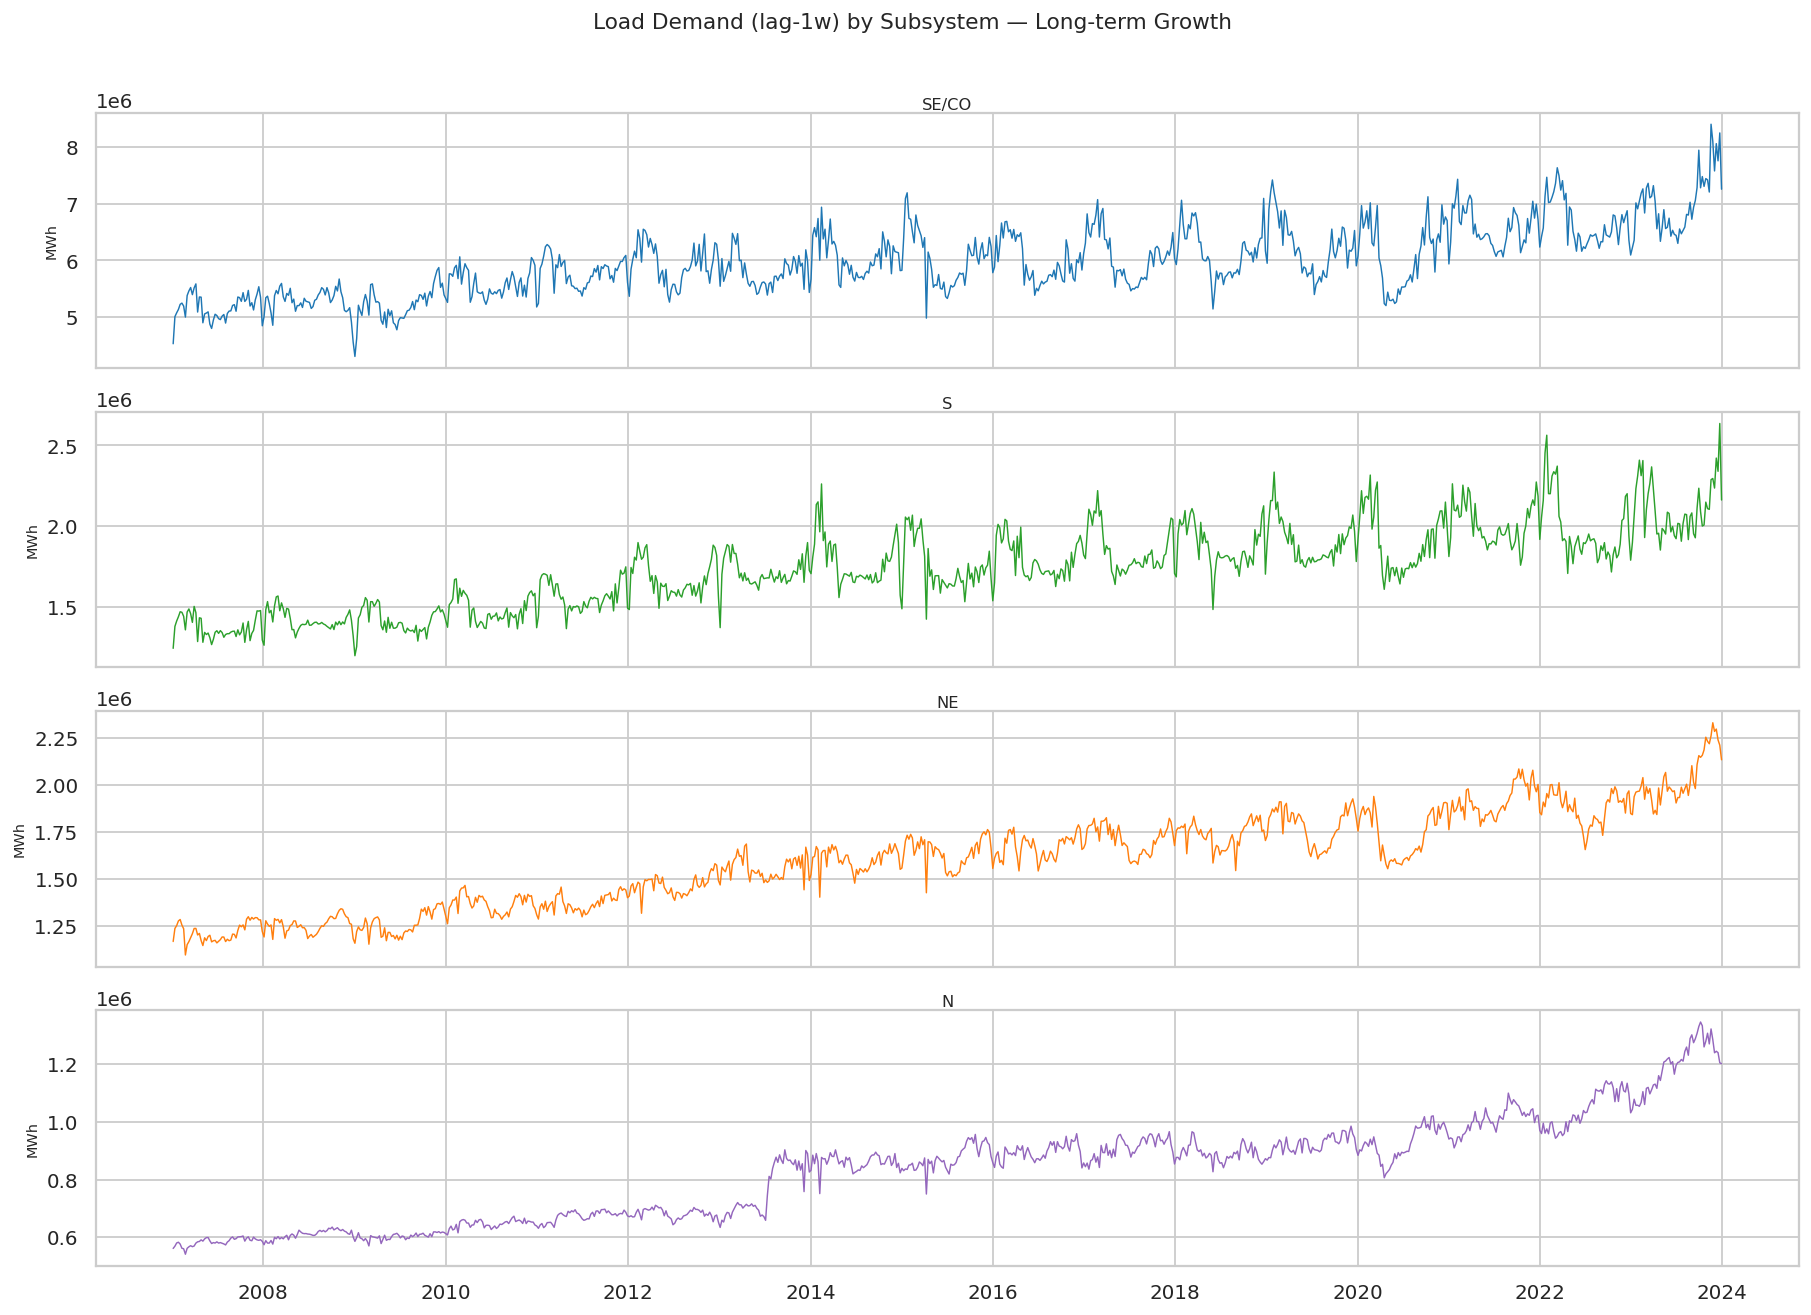

In [14]:
# Load time series — all subsystems
fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)

for ax, sub in zip(axes, SUBSYSTEMS):
    data = abt[abt["subsystem"] == sub].sort_values("week_start")
    ax.plot(data["week_start"], data["load_lag_1w"], color=COLORS[sub], linewidth=0.8)
    ax.set_ylabel("MWh", fontsize=8)
    ax.set_title(f"{sub}", fontsize=9, pad=2)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.xaxis.set_major_locator(mdates.YearLocator(2))

plt.suptitle("Load Demand (lag-1w) by Subsystem — Long-term Growth", fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

## 7. Weather: Precipitation & Temperature

Weather features are per-subsystem (one representative city each).
Precipitation is the direct driver of ENA (inflows). Temperature drives cooling/heating load.

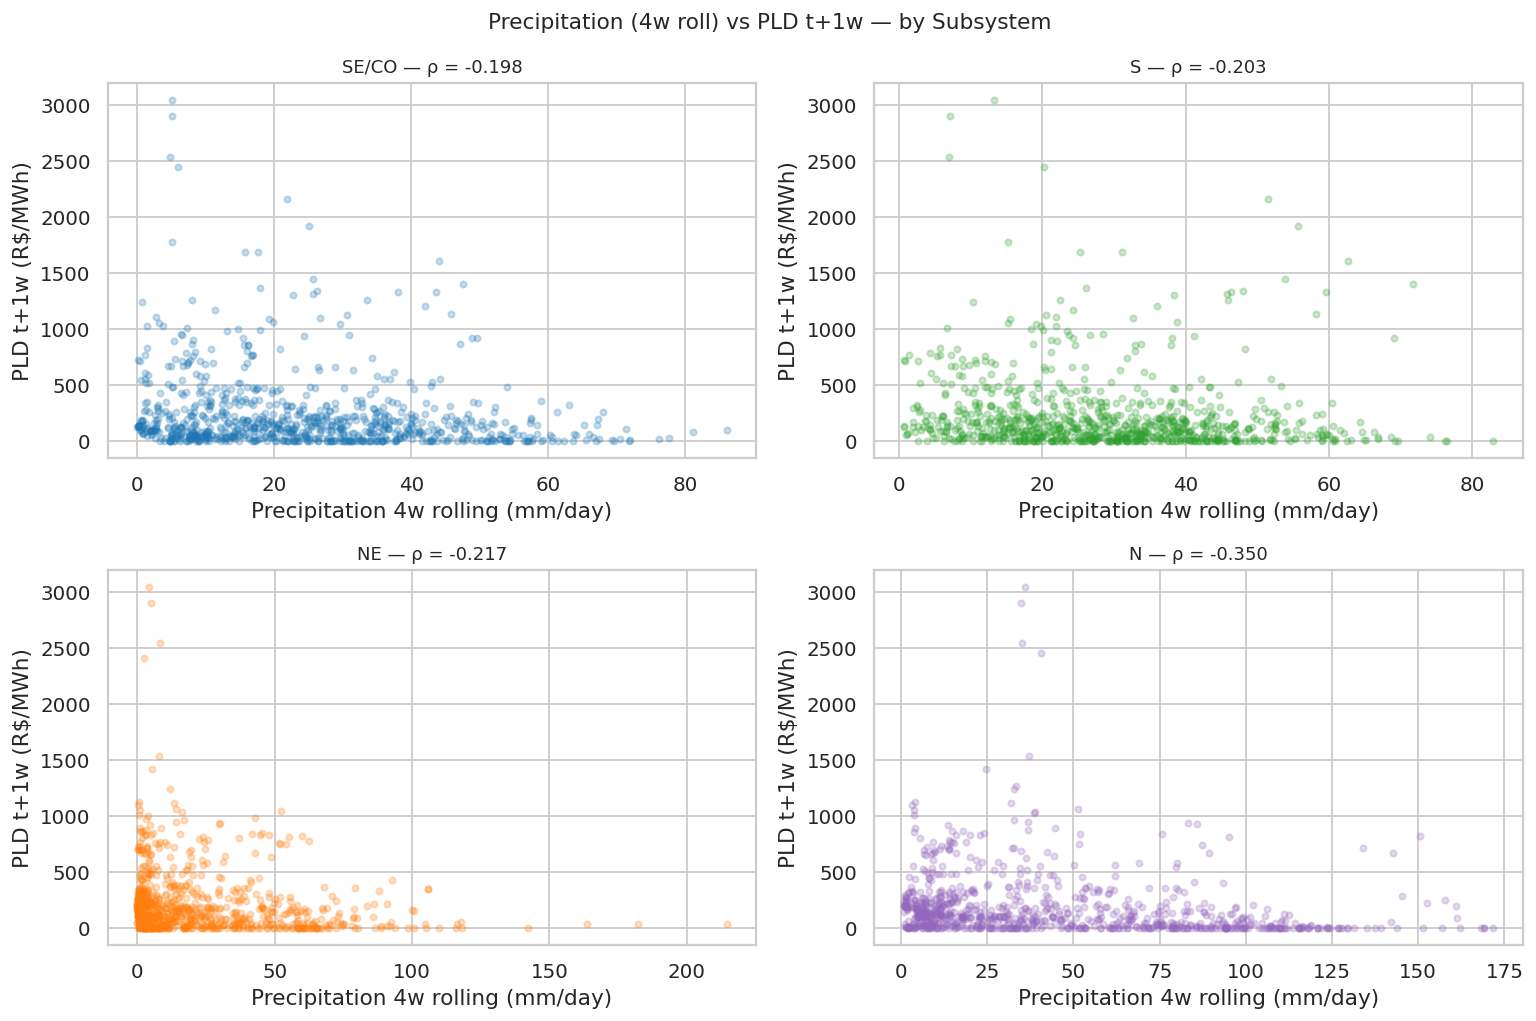

In [15]:
# Precipitation (rolling 4w) vs PLD — all subsystems
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for ax, sub in zip(axes, SUBSYSTEMS):
    mask = abt["subsystem"] == sub
    x = abt.loc[mask, "precip_roll_4w"]
    y = abt.loc[mask, "pld_t_plus_1w"]
    rho = x.corr(y, method="spearman")
    ax.scatter(x, y, alpha=0.25, s=12, color=COLORS[sub])
    ax.set_title(f"{sub} — ρ = {rho:.3f}", fontsize=10)
    ax.set_xlabel("Precipitation 4w rolling (mm/day)")
    ax.set_ylabel("PLD t+1w (R$/MWh)")

plt.suptitle("Precipitation (4w roll) vs PLD t+1w — by Subsystem", fontsize=12)
plt.tight_layout()
plt.show()

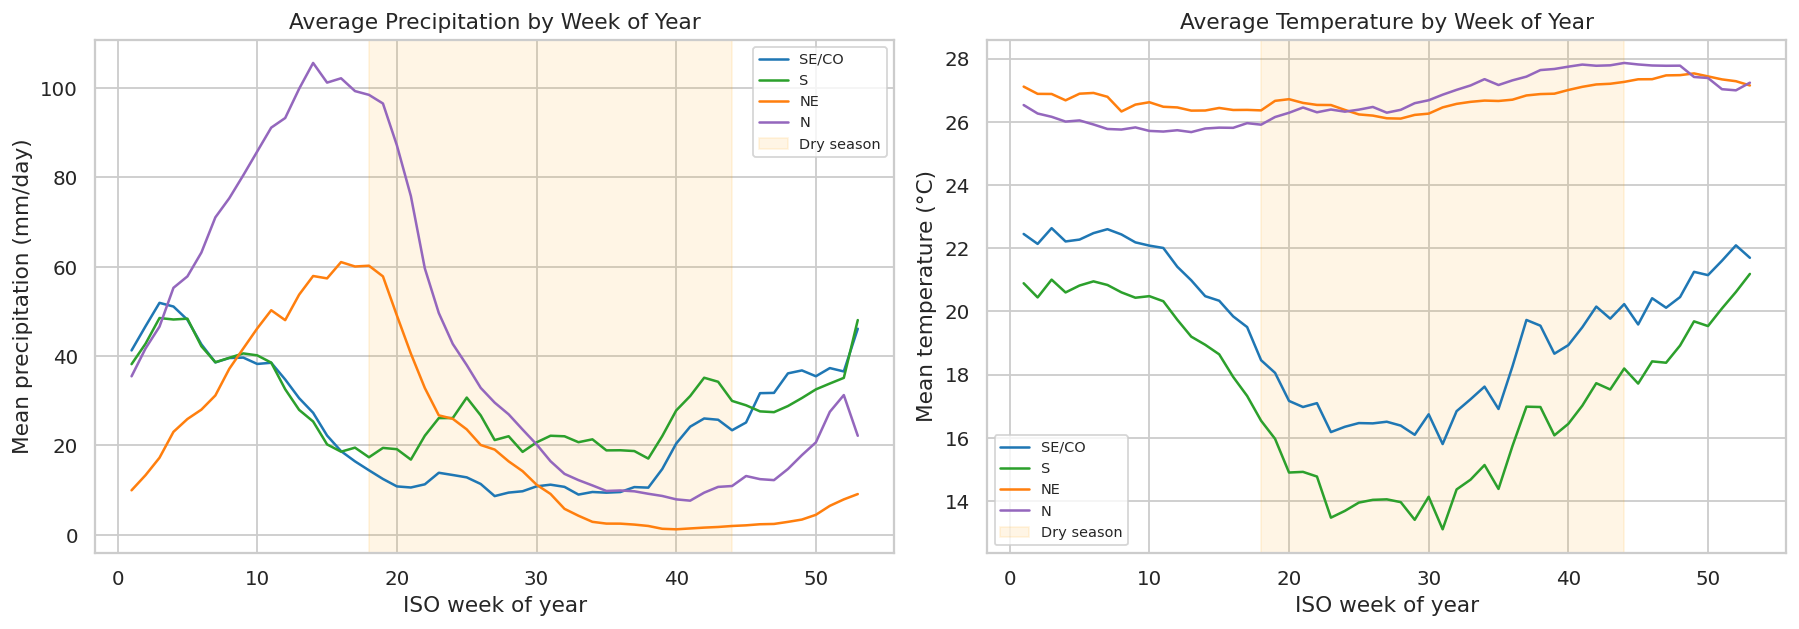

In [16]:
# Seasonal pattern of precipitation by subsystem (week-of-year average)
abt["week_of_year"] = abt["week_start"].dt.isocalendar().week.astype(int)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Precipitation seasonality
for sub in SUBSYSTEMS:
    mask = abt["subsystem"] == sub
    season = abt.loc[mask].groupby("week_of_year")["precip_roll_4w"].mean()
    axes[0].plot(season.index, season.values, color=COLORS[sub], linewidth=1.4, label=sub)
axes[0].axvspan(18, 44, alpha=0.10, color="orange", label="Dry season")
axes[0].set_xlabel("ISO week of year")
axes[0].set_ylabel("Mean precipitation (mm/day)")
axes[0].set_title("Average Precipitation by Week of Year")
axes[0].legend(fontsize=8)

# Temperature seasonality
for sub in SUBSYSTEMS:
    mask = abt["subsystem"] == sub
    season = abt.loc[mask].groupby("week_of_year")["temp_avg_lag_1w"].mean()
    axes[1].plot(season.index, season.values, color=COLORS[sub], linewidth=1.4, label=sub)
axes[1].axvspan(18, 44, alpha=0.10, color="orange", label="Dry season")
axes[1].set_xlabel("ISO week of year")
axes[1].set_ylabel("Mean temperature (°C)")
axes[1].set_title("Average Temperature by Week of Year")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

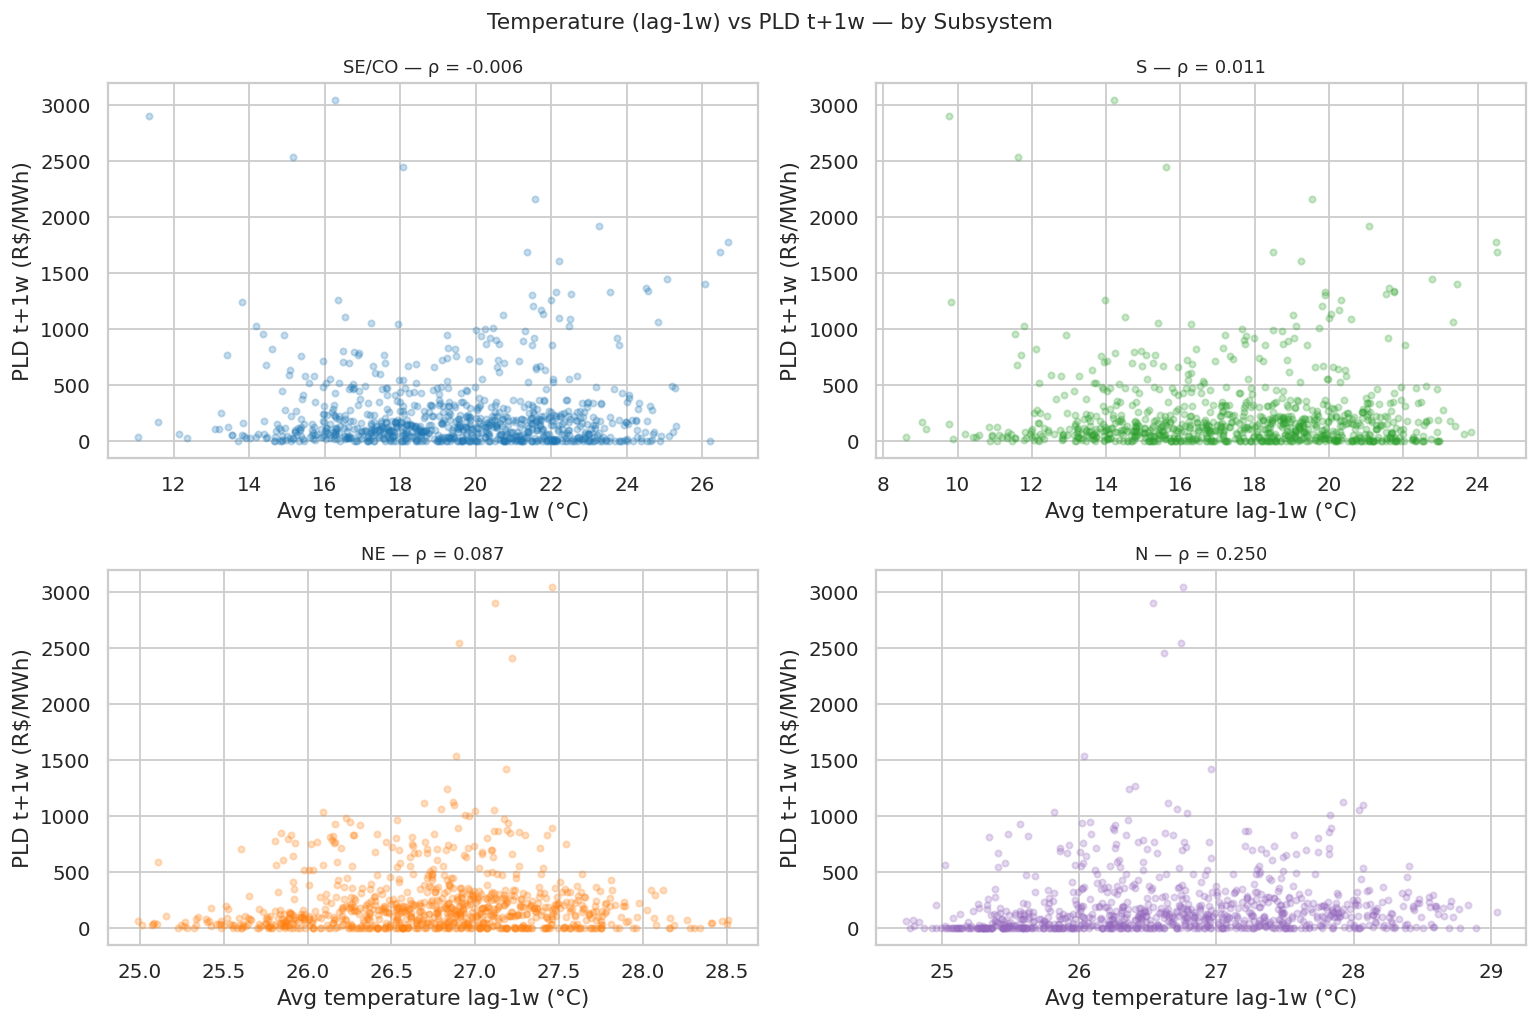

Note: Temperature's effect on PLD is indirect — high temp in dry season → high PLD
But in wet season, high temp → lower PLD (opposite sign). Non-linear / confounded.


In [17]:
# Temperature vs PLD — does heat increase PLD via cooling demand?
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for ax, sub in zip(axes, SUBSYSTEMS):
    mask = abt["subsystem"] == sub
    x = abt.loc[mask, "temp_avg_lag_1w"]
    y = abt.loc[mask, "pld_t_plus_1w"]
    rho = x.corr(y, method="spearman")
    ax.scatter(x, y, alpha=0.25, s=12, color=COLORS[sub])
    ax.set_title(f"{sub} — ρ = {rho:.3f}", fontsize=10)
    ax.set_xlabel("Avg temperature lag-1w (°C)")
    ax.set_ylabel("PLD t+1w (R$/MWh)")

plt.suptitle("Temperature (lag-1w) vs PLD t+1w — by Subsystem", fontsize=12)
plt.tight_layout()
plt.show()
print("Note: Temperature's effect on PLD is indirect — high temp in dry season → high PLD")
print("But in wet season, high temp → lower PLD (opposite sign). Non-linear / confounded.")

## 8. Cross-Subsystem Feature Patterns

The model uses all-subsystem ENA and reservoir features in each row.
Here we examine how correlated the subsystems are in their key physical drivers.

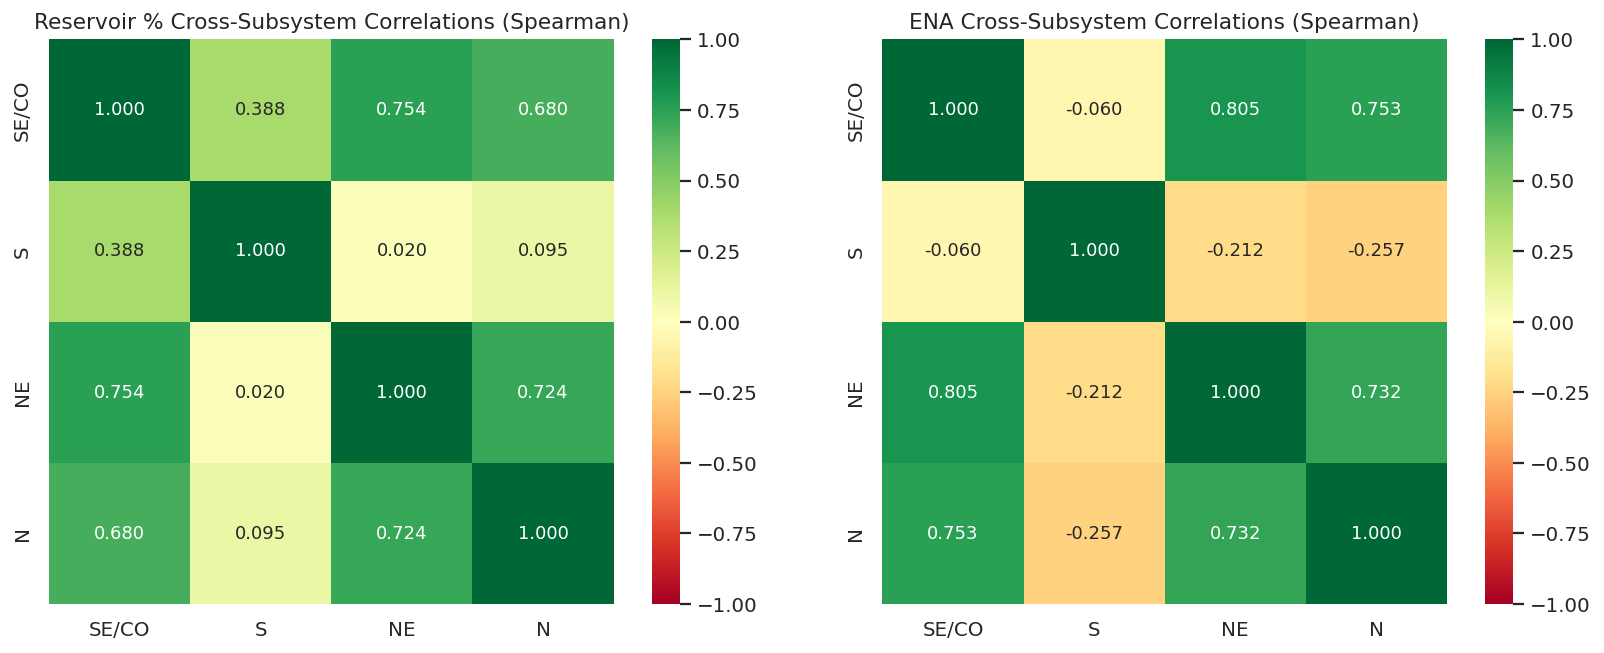

Low correlations → subsystems provide independent information (good for the model).
High correlations → subsystems are co-moving (e.g. national drought).


In [18]:
# Pairwise Spearman correlation of reservoir_*_lag_1w across subsystems
res_lag1_cols = ["reservoir_seco_lag_1w", "reservoir_s_lag_1w",
                 "reservoir_ne_lag_1w", "reservoir_n_lag_1w"]
res_labels = ["SE/CO", "S", "NE", "N"]

ena_lag1_cols = ["ena_seco_lag_1w", "ena_s_lag_1w", "ena_ne_lag_1w", "ena_n_lag_1w"]

# Use SE/CO rows (cross-subsystem features are the same in all rows for same week)
seco_rows = abt[abt["subsystem"] == "SE/CO"].copy()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Reservoir cross-subsystem correlation
res_corr = seco_rows[res_lag1_cols].rename(columns=dict(zip(res_lag1_cols, res_labels))).corr(method="spearman")
sns.heatmap(res_corr, annot=True, fmt=".3f", cmap="RdYlGn", vmin=-1, vmax=1,
            ax=axes[0], square=True, annot_kws={"size": 10})
axes[0].set_title("Reservoir % Cross-Subsystem Correlations (Spearman)")

# ENA cross-subsystem correlation
ena_corr = seco_rows[ena_lag1_cols].rename(columns=dict(zip(ena_lag1_cols, res_labels))).corr(method="spearman")
sns.heatmap(ena_corr, annot=True, fmt=".3f", cmap="RdYlGn", vmin=-1, vmax=1,
            ax=axes[1], square=True, annot_kws={"size": 10})
axes[1].set_title("ENA Cross-Subsystem Correlations (Spearman)")

plt.tight_layout()
plt.show()
print("Low correlations → subsystems provide independent information (good for the model).")
print("High correlations → subsystems are co-moving (e.g. national drought).")

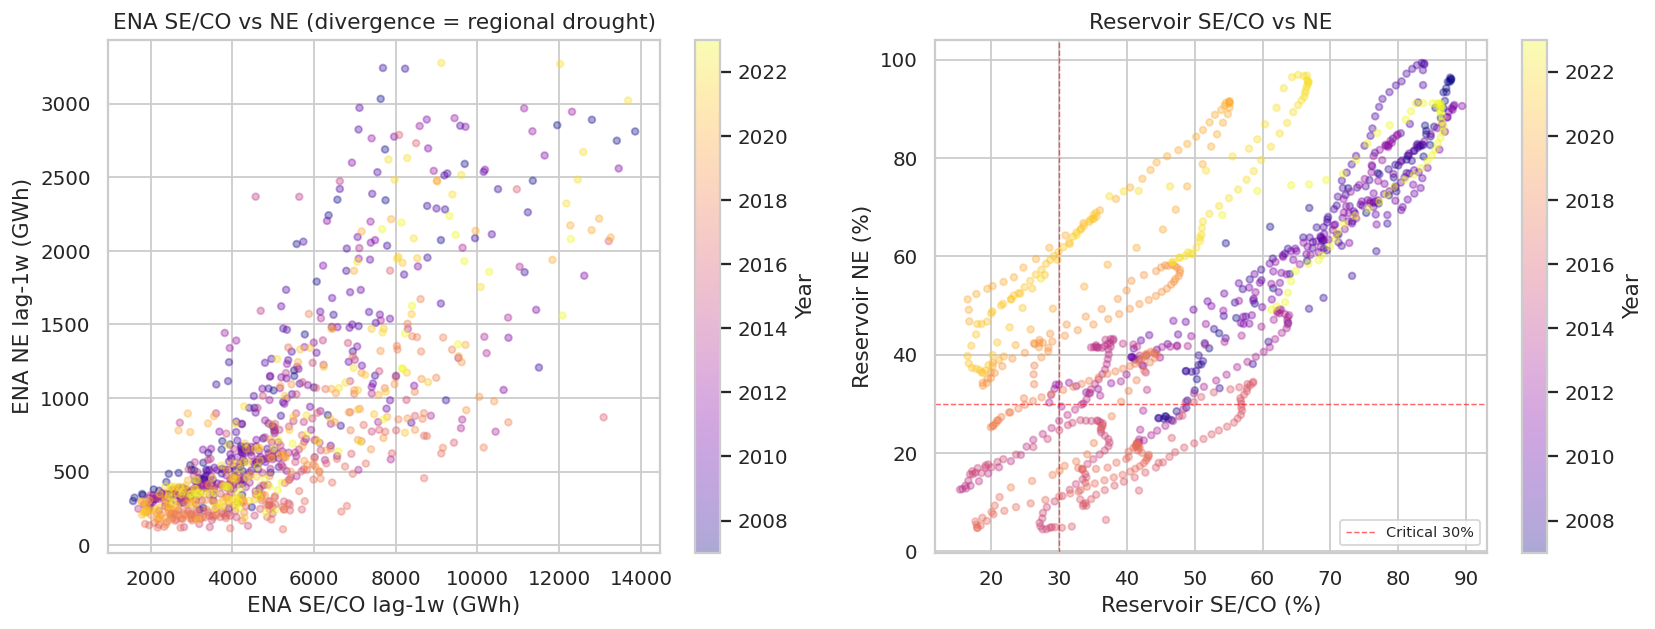

In [19]:
# ENA divergence between subsystems — scatter NE vs SE/CO
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

years = seco_rows["week_start"].dt.year

sc = axes[0].scatter(seco_rows["ena_seco_lag_1w"], seco_rows["ena_ne_lag_1w"],
                     c=years, cmap="plasma", alpha=0.35, s=14)
plt.colorbar(sc, ax=axes[0], label="Year")
axes[0].set_xlabel("ENA SE/CO lag-1w (GWh)")
axes[0].set_ylabel("ENA NE lag-1w (GWh)")
axes[0].set_title("ENA SE/CO vs NE (divergence = regional drought)")

sc2 = axes[1].scatter(seco_rows["reservoir_seco_lag_1w"], seco_rows["reservoir_ne_lag_1w"],
                      c=years, cmap="plasma", alpha=0.35, s=14)
plt.colorbar(sc2, ax=axes[1], label="Year")
axes[1].axhline(30, color="red", linestyle="--", linewidth=0.8, alpha=0.6)
axes[1].axvline(30, color="red", linestyle="--", linewidth=0.8, alpha=0.6, label="Critical 30%")
axes[1].set_xlabel("Reservoir SE/CO (%)")
axes[1].set_ylabel("Reservoir NE (%)")
axes[1].set_title("Reservoir SE/CO vs NE")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

## 9. Seasonal Feature Distributions (Dry vs. Wet Season)

The dry season (weeks 18–44, roughly May–October) is when PLD risk is highest.
Here we compare the distribution of key features across seasons.

/tmp/ipykernel_175708/3413722837.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_seco, x="season", y=col, ax=ax,
/tmp/ipykernel_175708/3413722837.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_seco, x="season", y=col, ax=ax,
/tmp/ipykernel_175708/3413722837.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_seco, x="season", y=col, ax=ax,
/tmp/ipykernel_175708/3413722837.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` 

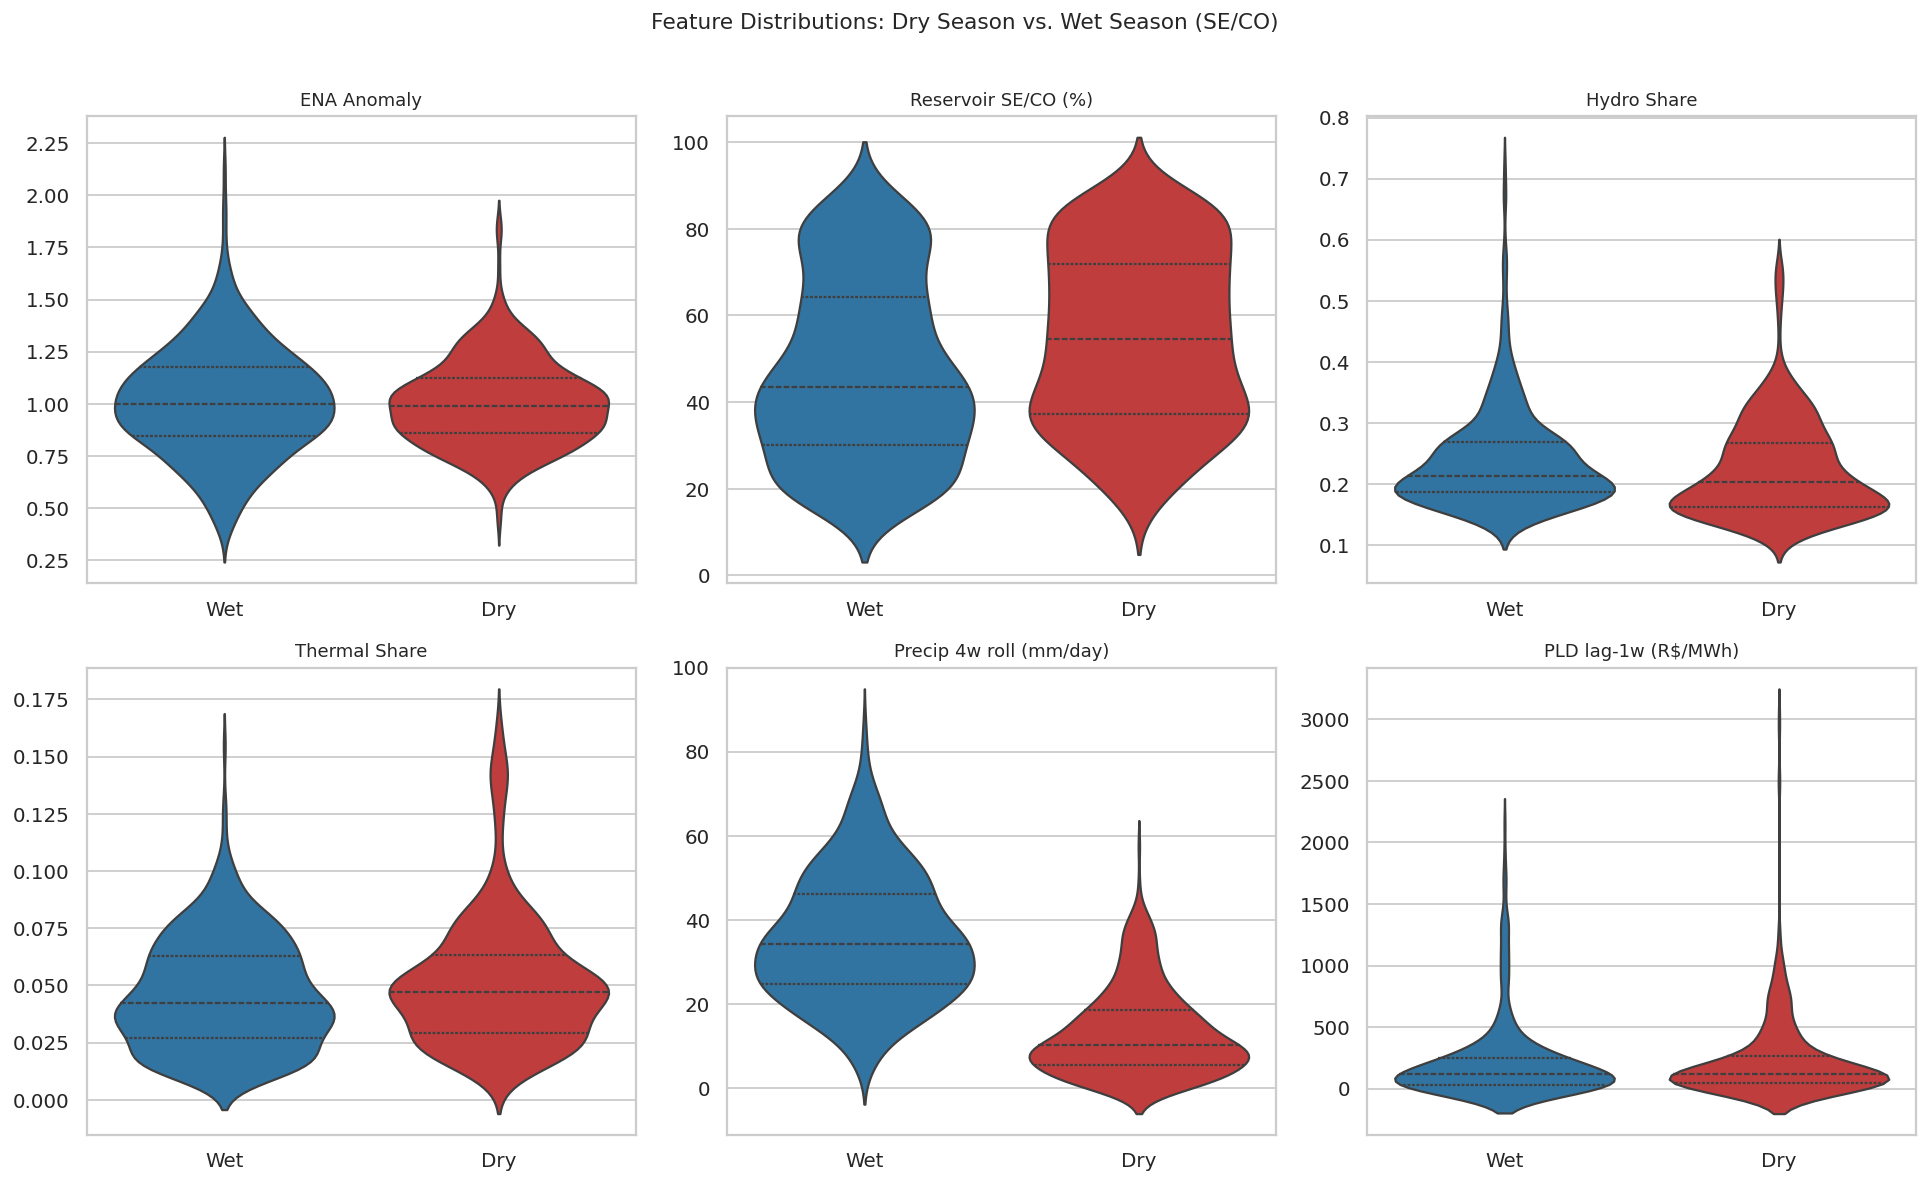

In [20]:
# Key features split by dry vs wet season — violin plots
key_features = [
    ("ena_anomaly",            "ENA Anomaly"),
    ("reservoir_seco_lag_1w",  "Reservoir SE/CO (%)"),
    ("hydro_share_lag_1w",     "Hydro Share"),
    ("thermal_share_lag_1w",   "Thermal Share"),
    ("precip_roll_4w",         "Precip 4w roll (mm/day)"),
    ("pld_lag_1w",             "PLD lag-1w (R$/MWh)"),
]

# Use SE/CO rows (national features same for all)
df_seco = abt[abt["subsystem"] == "SE/CO"].copy()
df_seco["season"] = df_seco["is_dry_season"].map({1: "Dry", 0: "Wet"})

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for ax, (col, label) in zip(axes, key_features):
    sns.violinplot(data=df_seco, x="season", y=col, ax=ax,
                   palette={"Dry": "#d62728", "Wet": "#1f77b4"}, inner="quartile")
    ax.set_title(label, fontsize=10)
    ax.set_xlabel("")
    ax.set_ylabel("")

plt.suptitle("Feature Distributions: Dry Season vs. Wet Season (SE/CO)", fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

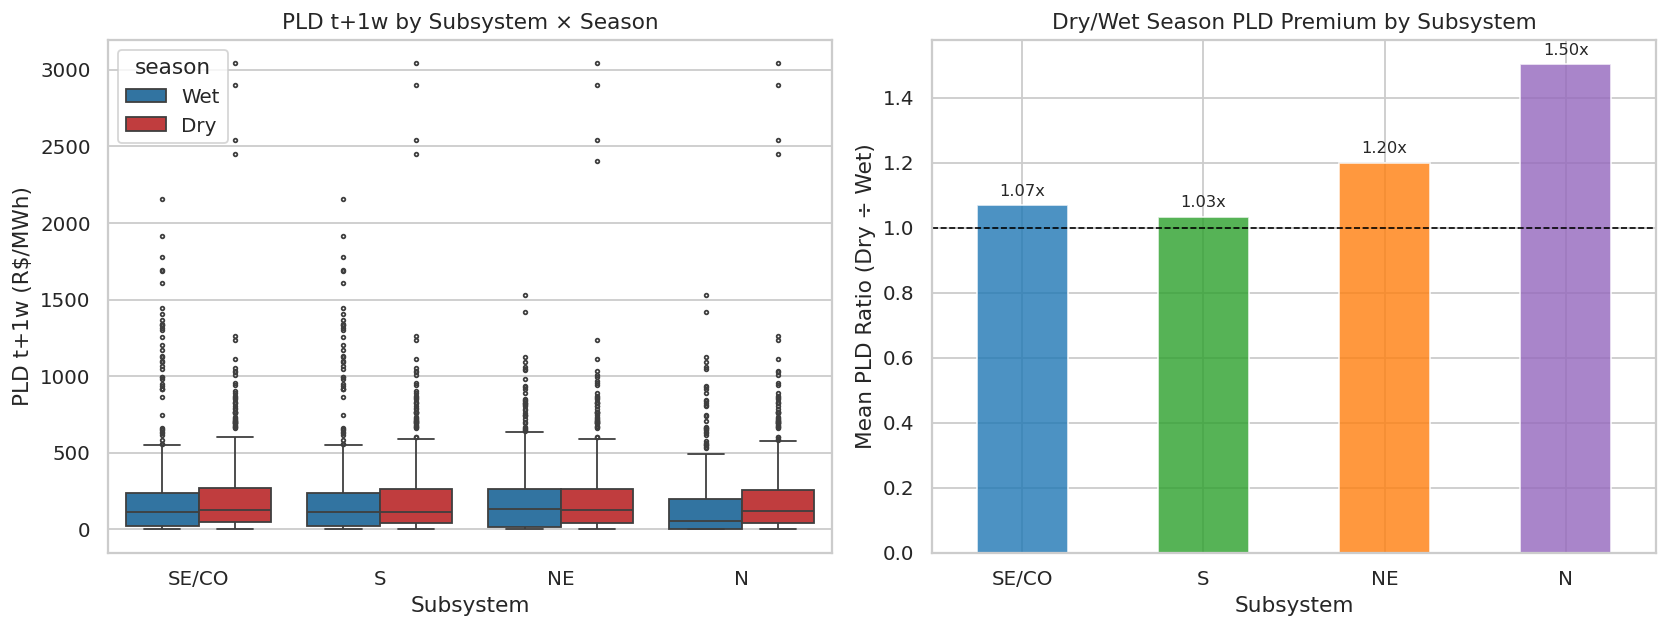

season       Dry    Wet  dry_wet_ratio
subsystem                             
N          223.3  148.5            1.5
NE         231.9  193.2            1.2
S          228.9  221.5            1.0
SE/CO      236.2  220.8            1.1


In [21]:
# Mean PLD by season × subsystem
season_pld = abt.copy()
season_pld["season"] = season_pld["is_dry_season"].map({1: "Dry", 0: "Wet"})

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Box plot: PLD t+1w by season × subsystem
sns.boxplot(
    data=season_pld, x="subsystem", y="pld_t_plus_1w", hue="season",
    palette={"Dry": "#d62728", "Wet": "#1f77b4"},
    order=SUBSYSTEMS, ax=axes[0], flierprops={"markersize": 2}
)
axes[0].set_title("PLD t+1w by Subsystem × Season")
axes[0].set_ylabel("PLD t+1w (R$/MWh)")
axes[0].set_xlabel("Subsystem")

# Mean PLD ratio (dry/wet) by subsystem
ratio = (
    season_pld.groupby(["subsystem", "season"])["pld_t_plus_1w"]
    .mean().unstack()
    .assign(dry_wet_ratio=lambda d: d["Dry"] / d["Wet"])
)
ratio["dry_wet_ratio"].reindex(SUBSYSTEMS).plot(
    kind="bar", ax=axes[1], color=[COLORS[s] for s in SUBSYSTEMS], alpha=0.8, rot=0
)
axes[1].axhline(1, color="black", linestyle="--", linewidth=0.9)
axes[1].set_title("Dry/Wet Season PLD Premium by Subsystem")
axes[1].set_ylabel("Mean PLD Ratio (Dry ÷ Wet)")
axes[1].set_xlabel("Subsystem")
for bar, sub in zip(axes[1].patches, SUBSYSTEMS):
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02,
                 f"{bar.get_height():.2f}x", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()
print(ratio[["Dry", "Wet", "dry_wet_ratio"]].round(1).to_string())